# Evalution of the method for classification task
We have seen how the removal of some dims of the shared representation can lead to a better performance on the clustering task and sometimes to match or even slightly improve the performance of the retrieval task.

In this section, we will evaluate the method on a classification task. We will use the same dataset and the same shared representation as before, but we will train a classifier on top of the shared representation to predict the class labels.

In [ ]:
import sys
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader    
from sklearn.decomposition import PCA
import tqdm as tqdm 
# os.chdir(os.path.dirname(os.path.abspath(__file__)))
sys.path.append(os.path.abspath(".."))

## Cifar 10

### Shared code

### Baseline
Train the classifier on the original clip embeddings concatenated.

### Original space subdimensions

### Aligned space subdimensions

## Cifar independent modalities

## MSCOCO with imagenet labels

### Shared code

### Baseline
Train the classifier on the original clip embeddings concatenated.

### Original space subdimensions

### Aligned space subdimensions

##  Mscoco Imagenet Independent modalities

## Flickr30k

### Shared code

### Baseline
Train the classifier on the original clip embeddings concatenated.

### Original space subdimensions

### Aligned space subdimensions

## Flickr30k Independent modalities

## MSRVTT concatenated modalities

### Shared code

#### Plan

1. Load the MSRVTT precomputed train/test embeddings and the semantic labels returned by the dataset.
2. Fit the subspace-alignment model on the **training split only**.
3. Reproduce the MSRVTT dimension-selection recipe from `few_dimensions.ipynb`:
   - compute the per-dimension modality gap on train,
   - compute the subspace joint-importance,
   - run the same Optuna threshold search on retrieval + clustering,
   - keep the selected dimensions and store the removed ones as their complement.
4. Train three linear probes with the same training loop:
   - **Scenario 1:** full original embeddings,
   - **Scenario 2:** original embeddings filtered to the selected dimensions,
   - **Scenario 3:** aligned embeddings filtered to the selected dimensions.
5. Log train/test accuracy and gap metrics to W&B and plot a compact comparison.

#### TODO

- [ ] Build MSRVTT train/test loaders and remap labels to contiguous class ids
- [ ] Fit subspace alignment on train and select the MSRVTT dimensions
- [ ] Train scenario 1 on the full original space
- [ ] Train scenario 2 on the filtered original space
- [ ] Train scenario 3 on the filtered aligned space
- [ ] Summarize train/test accuracy and gap metrics with plots


In [2]:
import copy
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    import wandb
except ImportError as exc:
    raise ImportError("wandb is required for this notebook. Install it with `pip install wandb`.") from exc

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for the MSRVTT dimension search. Install it with `pip install optuna`.") from exc

sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloader import (
    MSRVTTEmbeddingsDataset,
    msrvtt_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt
from models.fusion_mlp_classifier import LinearProbing


SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

DEVICE = os.environ.get("MSRVTT_CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PRECOMPUTED_TRAIN_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_train"
PRECOMPUTED_TEST_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_test"

ALLOW_MULTI_CAPTION = True
TEXT_INDEX = 0
BATCH_SIZE = 512
NUM_WORKERS = 0

D_SUB = 256
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4

WANDB_ENABLED = True
WANDB_PROJECT = "msrvtt_clip_classifier"
WANDB_GROUP = "msrvtt_linear_probe_subspace"

BASE_SAVE_DIR = Path("msrvtt_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

MSRVTT_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 20,
}

/opt/anaconda3/envs/few_dim_modalitygap/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda:1


In [3]:
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)

def extract_labels_from_dataset(dataset, desc="labels"):
    labels = []
    for idx in tqdm(range(len(dataset)), desc=desc):
        item = dataset[idx]
        if len(item) < 3:
            raise ValueError("MSRVTT dataset is expected to return at least (text, vision, label).")
        labels.append(label_to_int(item[2]))
    return np.asarray(labels, dtype=np.int64)

def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()

            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    mu_x = X.mean(axis=0)
    mu_y = Y.mean(axis=0)

    gap_dim = np.abs(mu_x - mu_y)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-importance)
        idx = order[:min_dims]
    return np.sort(idx)

ds_train = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TRAIN_DIR,
    split_name="train_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

ds_test = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TEST_DIR,
    split_name="test_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

train_loader = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

test_loader = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

embedding_dim = int(ds_train[0][0].shape[-1])
num_classes = len(set(extract_labels_from_dataset(ds_train, desc="Extracting train labels")))
label_lut_cpu = {label: idx for idx, label in enumerate(sorted(set(extract_labels_from_dataset(ds_train, desc="Building label LUT"))))}
label_lut_cpu = torch.Tensor([label_lut_cpu[label] for label in sorted(label_lut_cpu.keys())])
# convert to int for later use
label_lut_cpu = label_lut_cpu.long()

print(f"Train samples: {len(ds_train)}")
print(f"Test samples : {len(ds_test)}")
print(f"Number of classes: {num_classes}")
print(f"Embedding dimension: {embedding_dim}")

[Loaded MSRVTT] 57344 samples from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_train | vision_emb shape=(57344, 512) | num_classes=20
[Loaded MSRVTT] 884 samples from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_test | vision_emb shape=(884, 512) | num_classes=20


Building label LUT: 100%|██████████| 57344/57344 [00:00<00:00, 59434.22it/s]

Train samples: 57344
Test samples : 884
Number of classes: 20
Embedding dimension: 512


Fitting MSRVTT subspace alignment model...


Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


Best MSRVTT thresholds:
  imp_thr: 0.1085
  gap_thr: 0.588
  selected_dims: 508
  removed_dims: 4
  best_score: 0.7244491186529378
  retrieval_orig@1: 0.41218288242816925
  retrieval_aligned@1: 0.4113428294658661
  v_measure_orig: 0.27025956934854883
  v_measure_aligned: 0.35511295606329135
First 20 selected dims: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
First 20 removed dims : [70, 152, 253, 307]


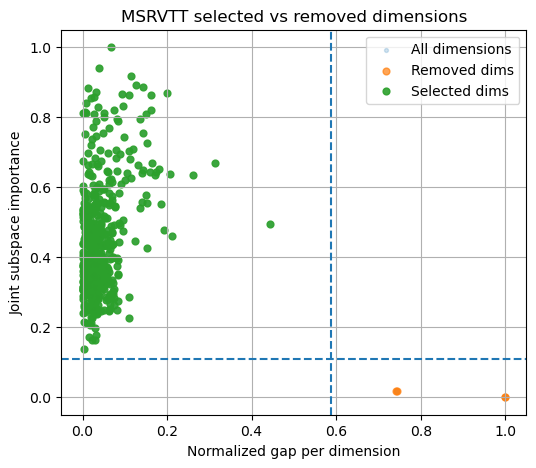

In [4]:
def eval_thresholds_msrvtt(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    important_joint_dims,
    gap_dims,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = select_dims(
        important_joint_dims,
        gap_dims,
        imp_thr,
        gap_thr,
        min_dims=min_dims,
    )

    r_orig = {1: [], 5: [], 10: []}
    r_aligned = {1: [], 5: [], 10: []}

    gaps_orig_batches = {g: [] for g in GAP_NAMES}
    gaps_aligned_batches = {g: [] for g in GAP_NAMES}

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="MSRVTT threshold evaluation", leave=False):
            text_b, vis_b, labels = batch[:3]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X
            elif direction != "text_to_vision":
                raise ValueError(f"Unknown direction: {direction}")

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=1)))
            r_orig[5].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=5)))
            r_orig[10].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=10)))

            Xn, _, Yaln = apply_subspace_alignment(X, Y, sub_model)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_aligned[1].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=1)))
            r_aligned[5].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=5)))
            r_aligned[10].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=10)))

            for gap_name in GAP_NAMES:
                gaps_orig_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xs, Ys, iterations=None))
                )
                gaps_aligned_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xal_s, Yal_s, iterations=None))
                )

            if labels is not None and seen < max_cluster_samples:
                labels_t = torch.as_tensor(labels)
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                labels_buf.append(labels_t[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    clustering_orig = None
    clustering_aligned = None
    if labels_buf:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        labels_all = torch.cat(labels_buf, dim=0)

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_all, labels_all, n_clusters=n_clusters
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_al_all, labels_all, n_clusters=n_clusters
        )

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_aligned.items()},
        "gaps_orig": {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()},
        "gaps_aligned": {g: float(np.mean(v)) for g, v in gaps_aligned_batches.items()},
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }
    return metrics

print("Fitting MSRVTT subspace alignment model...")
sub_model = fit_subspace_alignment(
    train_loader,
    n_fit=10_000,
    d_sub=D_SUB,
    device=DEVICE,
)

important_dims_txt, important_dims_vid, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=DEVICE,
)
gap_dims, top_gap_idx = get_dims_gap(train_loader, device=DEVICE)

# We get the thresholds from the file few_dimensions.ipynb
imp_thr = 0.1085
gap_thr = 0.5880

metrics = eval_thresholds_msrvtt(
    imp_thr=imp_thr,
    gap_thr=gap_thr,
    test_loader=test_loader,
    sub_model=sub_model,
    important_joint_dims=important_joint_dims,
    gap_dims=gap_dims,
    device=DEVICE,
    max_eval_batches=MSRVTT_SEARCH_CFG["max_eval_batches"],
    max_cluster_samples=MSRVTT_SEARCH_CFG["max_cluster_samples"],
    n_clusters=MSRVTT_SEARCH_CFG["n_clusters"],
    direction=MSRVTT_SEARCH_CFG["direction"],
    min_dims=MSRVTT_SEARCH_CFG["min_dims"],
)
r1_orig = metrics["retrieval_orig"][1]
r1_aligned = metrics["retrieval_aligned"][1]
v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
v_aligned = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0


selected_dims_msrvtt = np.asarray(metrics["dim_idx"], dtype=np.int64)
removed_dims_msrvtt = np.setdiff1d(np.arange(embedding_dim), selected_dims_msrvtt)
selected_dims_msrvtt_t = torch.as_tensor(selected_dims_msrvtt, dtype=torch.long, device=DEVICE)

dimension_search_summary = {
    "imp_thr": imp_thr,
    "gap_thr": gap_thr,
    "selected_dims": int(selected_dims_msrvtt.size),
    "removed_dims": int(removed_dims_msrvtt.size),
    "best_score": 0.5 * (r1_orig + r1_aligned) + 0.5 * (v_orig + v_aligned),
    "retrieval_orig@1": float(r1_orig),
    "retrieval_aligned@1": float(r1_aligned),
    "v_measure_orig": float(v_orig) if v_orig is not None else float("nan"),
    "v_measure_aligned": float(v_aligned) if v_aligned is not None else float("nan"),
}

print("Best MSRVTT thresholds:")
for key, value in dimension_search_summary.items():
    print(f"  {key}: {value}")

print("First 20 selected dims:", selected_dims_msrvtt[:20].tolist())
print("First 20 removed dims :", removed_dims_msrvtt[:20].tolist())

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[selected_dims_msrvtt] = False

plt.scatter(
    gap_dims[removed_mask],
    important_joint_dims[removed_mask],
    s=24,
    alpha=0.7,
    label="Removed dims",
)
plt.scatter(
    gap_dims[selected_dims_msrvtt],
    important_joint_dims[selected_dims_msrvtt],
    s=24,
    alpha=0.9,
    label="Selected dims",
)
plt.axvline(gap_thr, linestyle="--")
plt.axhline(imp_thr, linestyle="--")
plt.xlabel("Normalized gap per dimension")
plt.ylabel("Joint subspace importance")
plt.title("MSRVTT selected vs removed dimensions")
plt.grid(True)
plt.legend()
plt.show()

In [5]:
def make_optimizer_and_scheduler(model, train_loader, epochs=20, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e4,
        anneal_strategy="cos",
    )
    return optimizer, scheduler

def remap_labels(labels_gpu: torch.Tensor, lut_gpu: torch.Tensor) -> torch.Tensor:
    if labels_gpu.numel() == 0:
        return labels_gpu

    if labels_gpu.min().item() < 0 or labels_gpu.max().item() >= lut_gpu.numel():
        raise ValueError(
            f"Labels out of LUT range. min={labels_gpu.min().item()} max={labels_gpu.max().item()} lut_size={lut_gpu.numel()}"
        )

    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].detach().cpu().numpy()
        raise ValueError(f"Found labels missing from the train label map. Examples: {bad}")
    return mapped

def prepare_features_for_scenario(
    text_emb,
    vision_emb,
    scenario_mode,
    selected_dims=None,
    sub_model=None,
    device="cuda",
):
    if scenario_mode == "baseline":
        return text_emb, vision_emb

    if selected_dims is None:
        raise ValueError("selected_dims must be provided for the filtered scenarios.")

    if scenario_mode == "original_filtered":
        return (
            text_emb.index_select(dim=1, index=selected_dims),
            vision_emb.index_select(dim=1, index=selected_dims),
        )

    if scenario_mode == "aligned_filtered":
        if sub_model is None:
            raise ValueError("sub_model must be provided for the aligned scenario.")
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return (
            X_al.index_select(dim=1, index=selected_dims),
            Y_al.index_select(dim=1, index=selected_dims),
        )

    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")

def train_linear_probe_msrvtt(
    scenario_name,
    scenario_mode,
    train_loader,
    test_loader,
    num_classes,
    feature_dim,
    device="cuda",
    selected_dims=None,
    sub_model=None,
    epochs=200,
    patience=20,
    max_lr=3e-4,
    weight_decay=1e-4,
    wandb_enabled=True,
    wandb_project="msrvtt_clip_classifier",
    wandb_group="msrvtt_linear_probe_subspace",
    extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbing(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model,
        train_loader,
        epochs=epochs,
        max_lr=max_lr,
        weight_decay=weight_decay,
    )

    lut_gpu = label_lut_cpu.to(device)
    selected_dims_t = None
    if selected_dims is not None:
        selected_dims_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device)

    run = None
    run_config = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "num_classes": int(num_classes),
        "epochs": int(epochs),
        "patience": int(patience),
        "max_lr": float(max_lr),
        "weight_decay": float(weight_decay),
        "d_sub": int(D_SUB),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
    }
    if extra_config is not None:
        run_config.update(extra_config)

    if wandb_enabled:
        run = wandb.init(
            project=wandb_project,
            group=wandb_group,
            name=scenario_name,
            config=run_config,
            reinit=True,
        )

    history = {
        "train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
        "test": {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}},
    }

    best_test_loss = float("inf")
    best_test_acc = 0.0
    best_loss_state = None
    best_acc_state = None
    epochs_no_improve = 0

    def run_epoch(dataloader, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()

        losses, accs, lrs = [], [], []
        gap_values = {g: [] for g in GAP_NAMES}

        iterator = tqdm(dataloader, desc=f"{scenario_name} | {phase}", leave=False)
        for batch in iterator:
            text_emb, vision_emb, labels = batch[:3]

            text_emb = text_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            vision_emb = vision_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            labels = torch.as_tensor(labels, device=device, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb,
                vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=selected_dims_t,
                sub_model=sub_model,
                device=device,
            )

            logits = model(text_feat, vision_feat)
            loss = criterion(logits, labels)

            if is_train:
                loss.backward()
                clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            acc = (logits.argmax(dim=1) == labels).float().mean()

            losses.append(float(loss.item()))
            accs.append(float(acc.item()))
            if is_train:
                lrs.append(float(optimizer.param_groups[0]["lr"]))

            with torch.no_grad():
                text_det = text_feat.detach()
                vision_det = vision_feat.detach()
                for gap_name in GAP_NAMES:
                    gap_values[gap_name].append(
                        gap_to_float(compute_gap(gap_name, text_det, vision_det, iterations=None))
                    )

        mean_loss = float(np.mean(losses)) if losses else float("nan")
        mean_acc = float(np.mean(accs)) if accs else float("nan")
        mean_lr = float(np.mean(lrs)) if (is_train and lrs) else None
        mean_gaps = {gap_name: float(np.mean(values)) for gap_name, values in gap_values.items()}

        return mean_loss, mean_acc, mean_lr, mean_gaps

    for epoch in range(epochs):
        train_loss, train_acc, train_lr, train_gaps = run_epoch(train_loader, phase="train")
        with torch.no_grad():
            test_loss, test_acc, _, test_gaps = run_epoch(test_loader, phase="test")

        history["train"]["loss"].append(train_loss)
        history["train"]["accuracy"].append(train_acc)
        history["train"]["lr"].append(train_lr if train_lr is not None else float("nan"))
        for gap_name in GAP_NAMES:
            history["train"][gap_name].append(train_gaps[gap_name])

        history["test"]["loss"].append(test_loss)
        history["test"]["accuracy"].append(test_acc)
        for gap_name in GAP_NAMES:
            history["test"][gap_name].append(test_gaps[gap_name])

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"[{scenario_name}] epoch {epoch + 1}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

        improved = False

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_loss_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_loss",
                    "metric_value": best_test_loss,
                    "model_state_dict": best_loss_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_loss.pt",
            )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_acc_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_accuracy",
                    "metric_value": best_test_acc,
                    "model_state_dict": best_acc_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_acc.pt",
            )

        if improved:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if run is not None:
            payload = {
                "epoch": epoch + 1,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "train/lr": train_lr,
                "test/loss": test_loss,
                "test/accuracy": test_acc,
                "best/test_loss": best_test_loss,
                "best/test_accuracy": best_test_acc,
                "early_stop/epochs_no_improve": epochs_no_improve,
            }
            for gap_name in GAP_NAMES:
                payload[f"train/{gap_name}"] = train_gaps[gap_name]
                payload[f"test/{gap_name}"] = test_gaps[gap_name]
            wandb.log(payload)

        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch + 1} / {epochs}")
            break

    if best_acc_state is not None:
        model.load_state_dict(best_acc_state)
        best_checkpoint_metric = "test_accuracy"
    elif best_loss_state is not None:
        model.load_state_dict(best_loss_state)
        best_checkpoint_metric = "test_loss"
    else:
        best_checkpoint_metric = "last_epoch"

    with torch.no_grad():
        final_train_loss, final_train_acc, _, final_train_gaps = run_epoch(train_loader, phase="test")
        final_test_loss, final_test_acc, _, final_test_gaps = run_epoch(test_loader, phase="test")

    result = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
        "removed_dims_count": int(embedding_dim - len(selected_dims)) if selected_dims is not None else 0,
        "best_checkpoint_metric": best_checkpoint_metric,
        "best_test_loss": float(best_test_loss),
        "best_test_acc": float(best_test_acc),
        "final_train_loss": float(final_train_loss),
        "final_train_acc": float(final_train_acc),
        "final_test_loss": float(final_test_loss),
        "final_test_acc": float(final_test_acc),
        "final_train_gaps": {k: float(v) for k, v in final_train_gaps.items()},
        "final_test_gaps": {k: float(v) for k, v in final_test_gaps.items()},
        "history": history,
        "checkpoint_dir": str(scenario_dir),
    }

    with open(scenario_dir / "summary.json", "w") as f:
        json.dump(result, f, indent=2)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "result": result,
            "config": run_config,
        },
        scenario_dir / "best_model_loaded_final.pt",
    )

    if run is not None:
        run.summary["best_test_loss"] = result["best_test_loss"]
        run.summary["best_test_acc"] = result["best_test_acc"]
        run.summary["final_train_acc"] = result["final_train_acc"]
        run.summary["final_test_acc"] = result["final_test_acc"]
        run.summary["selected_dims_count"] = result["selected_dims_count"]
        run.summary["removed_dims_count"] = result["removed_dims_count"]
        for gap_name in GAP_NAMES:
            run.summary[f"final_train_{gap_name}"] = result["final_train_gaps"][gap_name]
            run.summary[f"final_test_{gap_name}"] = result["final_test_gaps"][gap_name]
        run.finish()

    print(
        f"[{scenario_name}] done | best_test_acc={result['best_test_acc']:.4f} | "
        f"final_test_acc={result['final_test_acc']:.4f}"
    )
    return result

def build_summary_table(results_dict):
    rows = []
    for scenario_name, result in results_dict.items():
        row = {
            "scenario": scenario_name,
            "feature_dim": result["feature_dim"],
            "selected_dims": result["selected_dims_count"],
            "removed_dims": result["removed_dims_count"],
            "best_test_acc": result["best_test_acc"],
            "best_test_loss": result["best_test_loss"],
            "final_train_acc": result["final_train_acc"],
            "final_test_acc": result["final_test_acc"],
            "final_train_loss": result["final_train_loss"],
            "final_test_loss": result["final_test_loss"],
        }
        for gap_name in GAP_NAMES:
            row[f"train_{gap_name}"] = result["final_train_gaps"][gap_name]
            row[f"test_{gap_name}"] = result["final_test_gaps"][gap_name]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)

def plot_metric_history(results_dict, split, metric, title):
    plt.figure(figsize=(8, 5))
    for scenario_name, result in results_dict.items():
        plt.plot(result["history"][split][metric], label=scenario_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_final_metric_bars(summary_df, metric, title):
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["scenario"], summary_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.show()

scenario_results = {}

### Baseline
Train the classifier on the original clip embeddings concatenated.

In [6]:
scenario_results["msrvtt_s1_full_original"] = train_linear_probe_msrvtt(
    scenario_name="msrvtt_s1_full_original",
    scenario_mode="baseline",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=embedding_dim,
    device=DEVICE,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "none",
        "notes": "Linear probe on the original full MSRVTT embeddings.",
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/emanuele/.netrc.
wandb: Currently logged in as: rucci-emanuele (rucci-emanuele-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[msrvtt_s1_full_original] epoch 1/200 | train_loss=2.9932 train_acc=0.0490 | test_loss=2.9861 test_acc=0.0807


[msrvtt_s1_full_original] epoch 11/200 | train_loss=2.5363 train_acc=0.4835 | test_loss=2.5021 test_acc=0.4954


[msrvtt_s1_full_original] epoch 21/200 | train_loss=1.8455 train_acc=0.6129 | test_loss=1.8758 test_acc=0.6172


[msrvtt_s1_full_original] epoch 31/200 | train_loss=1.5906 train_acc=0.6645 | test_loss=1.6871 test_acc=0.6506


...

[msrvtt_s1_full_original] epoch 101/200 | train_loss=1.1757 train_acc=0.8073 | test_loss=1.5628 test_acc=0.6577


[msrvtt_s1_full_original] epoch 111/200 | train_loss=1.1567 train_acc=0.8153 | test_loss=1.5643 test_acc=0.6563
[msrvtt_s1_full_original] early stop at epoch 111 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▂▂▄▅▇▇▇▇▇██████████████████████████████
best/test_loss,██▆▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▂▂▂▃▄▄▇▇█
epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇██
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▄▅▆▇▇▇▇████████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,██▇▆▆▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s1_full_original] done | best_test_acc=0.6670 | final_test_acc=0.6670


### Original space subdimensions

In [9]:
scenario_results["msrvtt_s2_original_filtered"] = train_linear_probe_msrvtt(
    scenario_name="msrvtt_s2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=int(len(selected_dims_msrvtt)),
    device=DEVICE,
    selected_dims=selected_dims_msrvtt,
    sub_model=None,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_threshold_search",
        "imp_thr": imp_thr,
        "gap_thr": gap_thr,
        "notes": "Linear probe on the original MSRVTT embeddings after removing the dimensions discarded by the subspace-based selector.",
    },
)

[msrvtt_s2_original_filtered] epoch 1/200 | train_loss=2.9916 train_acc=0.0608 | test_loss=2.9850 test_acc=0.0904


[msrvtt_s2_original_filtered] epoch 11/200 | train_loss=2.5428 train_acc=0.4916 | test_loss=2.5082 test_acc=0.5150


[msrvtt_s2_original_filtered] epoch 21/200 | train_loss=1.8492 train_acc=0.6136 | test_loss=1.8778 test_acc=0.6163


[msrvtt_s2_original_filtered] epoch 31/200 | train_loss=1.5934 train_acc=0.6640 | test_loss=1.6876 test_acc=0.6462


[msrvtt_s2_original_filtered] epoch 41/200 | train_loss=1.4666 train_acc=0.6966 | test_loss=1.6193 test_acc=0.6608


...

[msrvtt_s2_original_filtered] epoch 101/200 | train_loss=1.1768 train_acc=0.8069 | test_loss=1.5618 test_acc=0.6623


[msrvtt_s2_original_filtered] early stop at epoch 108 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▂▄▅▅▆▆▇▇▇██████████████████████████████
best/test_loss,███▇▇▅▄▄▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▃▁▂▂▃▅█
epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▄▅▅▆▇▇▇▇███████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,██▇▅▅▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s2_original_filtered] done | best_test_acc=0.6683 | final_test_acc=0.6683


### Aligned space subdimensions

In [10]:
scenario_results["msrvtt_s3_aligned_filtered"] = train_linear_probe_msrvtt(
    scenario_name="msrvtt_s3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=int(len(selected_dims_msrvtt)),
    device=DEVICE,
    selected_dims=selected_dims_msrvtt,
    sub_model=sub_model,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_threshold_search",
        "imp_thr": imp_thr,
        "gap_thr": gap_thr,
        "notes": "Linear probe on the aligned MSRVTT embeddings after removing the dimensions discarded by the subspace-based selector.",
    },
)



[msrvtt_s3_aligned_filtered] epoch 1/200 | train_loss=2.9958 train_acc=0.0416 | test_loss=2.9916 test_acc=0.0606


[msrvtt_s3_aligned_filtered] epoch 11/200 | train_loss=2.5364 train_acc=0.5032 | test_loss=2.4966 test_acc=0.5288


[msrvtt_s3_aligned_filtered] epoch 21/200 | train_loss=1.8447 train_acc=0.6108 | test_loss=1.8586 test_acc=0.6211


[msrvtt_s3_aligned_filtered] epoch 31/200 | train_loss=1.6065 train_acc=0.6560 | test_loss=1.6762 test_acc=0.6480


[msrvtt_s3_aligned_filtered] epoch 41/200 | train_loss=1.4954 train_acc=0.6844 | test_loss=1.6141 test_acc=0.6637


...

[msrvtt_s3_aligned_filtered] epoch 101/200 | train_loss=1.2612 train_acc=0.7671 | test_loss=1.5697 test_acc=0.6635


[msrvtt_s3_aligned_filtered] early stop at epoch 105 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▃▄▆▆▆▆▆▇▇██████████████████████████████
best/test_loss,█▇▇▆▅▄▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▄▅▅▆▇█
epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇███
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▄▆▆▆▆▆▇▇▇██████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,█▆▅▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s3_aligned_filtered] done | best_test_acc=0.6671 | final_test_acc=0.6671


### EXP recap

,scenario,feature_dim,selected_dims,removed_dims,best_test_acc,best_test_loss,final_train_acc,final_test_acc,final_train_loss,final_test_loss,train_RMG,test_RMG,train_L2M,test_L2M,train_L2I,test_L2I,train_cosineTP,test_cosineTP
0,msrvtt_s1_full_original,512,512,0,0.666950,1.561840,0.757499,0.666950,1.292950,1.569172,0.836985,0.837280,0.776572,0.778526,1.201227,1.199774,0.277460,0.279267
1,msrvtt_s2_original_filtered,508,508,4,0.668294,1.560669,0.777832,0.668294,1.243277,1.562271,0.790836,0.791471,0.480772,0.486786,1.019272,1.018157,0.276874,0.279003
2,msrvtt_s3_aligned_filtered,508,508,4,0.667076,1.567671,0.754656,0.667076,1.291485,1.567795,0.736950,0.737057,0.057253,0.065420,0.817570,0.813980,0.459270,0.462691


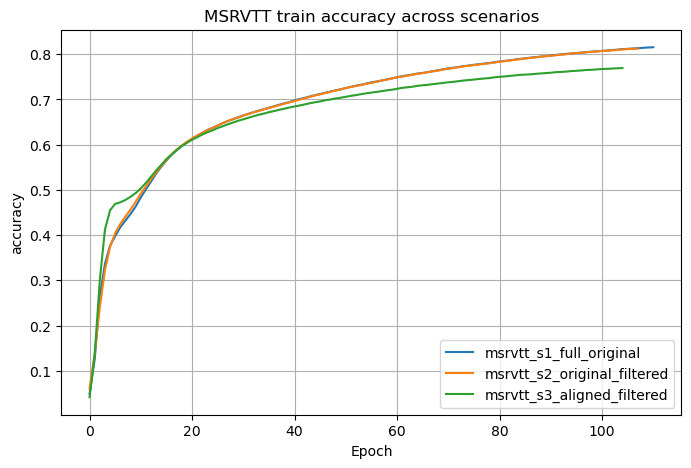

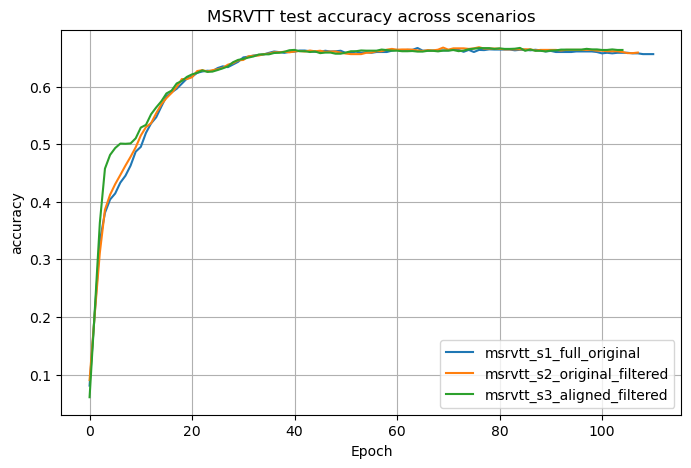

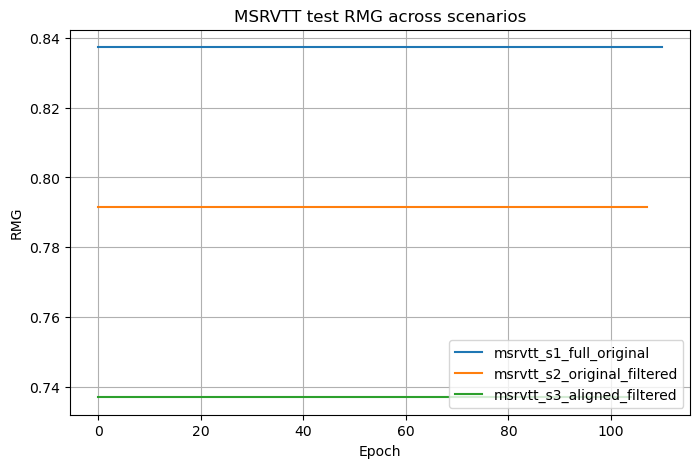

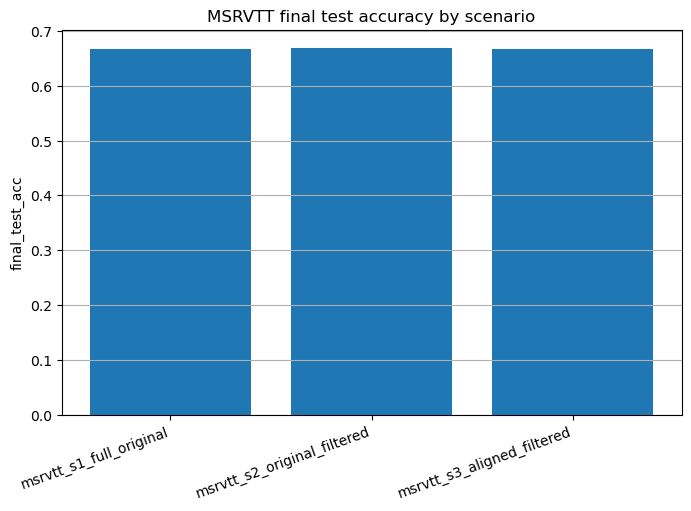

In [11]:
summary_df_msrvtt = build_summary_table(scenario_results)
display(summary_df_msrvtt)

plot_metric_history(
    scenario_results,
    split="train",
    metric="accuracy",
    title="MSRVTT train accuracy across scenarios",
)
plot_metric_history(
    scenario_results,
    split="test",
    metric="accuracy",
    title="MSRVTT test accuracy across scenarios",
)
plot_metric_history(
    scenario_results,
    split="test",
    metric="RMG",
    title="MSRVTT test RMG across scenarios",
)
plot_final_metric_bars(
    summary_df_msrvtt,
    metric="final_test_acc",
    title="MSRVTT final test accuracy by scenario",
)

### Run the models on the test set and get the values (loss and accuracy)

In [13]:
import json
from pathlib import Path

# ── Scenario configs: name → (scenario_mode, feature_dim, selected_dims, sub_model) ──
scenario_configs = {
    "msrvtt_s1_full_original": ("baseline", embedding_dim, None, None),
    "msrvtt_s2_original_filtered": ("original_filtered", int(len(selected_dims_msrvtt)), selected_dims_msrvtt, None),
    "msrvtt_s3_aligned_filtered": ("aligned_filtered", int(len(selected_dims_msrvtt)), selected_dims_msrvtt, sub_model),
}

lut_gpu = label_lut_cpu.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)

eval_results = {}

for scenario_name, (scenario_mode, feat_dim, sel_dims, s_model) in scenario_configs.items():
    ckpt_path = BASE_SAVE_DIR / scenario_name / "best_model_test_acc.pt"
    if not ckpt_path.exists():
        print(f"[{scenario_name}] checkpoint not found at {ckpt_path}, skipping.")
        continue

    # Load checkpoint
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model = LinearProbing(d=feat_dim, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    sel_dims_t = None
    if sel_dims is not None:
        sel_dims_t = torch.as_tensor(sel_dims, dtype=torch.long, device=DEVICE)

    # Evaluate on test set
    losses, accs = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Eval {scenario_name}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb = text_emb.to(device=DEVICE, dtype=torch.float32)
            vision_emb = vision_emb.to(device=DEVICE, dtype=torch.float32)
            labels = torch.as_tensor(labels, device=DEVICE, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=sel_dims_t,
                sub_model=s_model,
                device=DEVICE,
            )

            logits = model(text_feat, vision_feat)
            loss = criterion(logits, labels)
            acc = (logits.argmax(dim=1) == labels).float().mean()

            losses.append(loss.item())
            accs.append(acc.item())

    test_loss = float(np.mean(losses))
    test_acc = float(np.mean(accs))
    eval_results[scenario_name] = {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "ckpt_epoch": ckpt.get("epoch", "?"),
        "feature_dim": feat_dim,
    }
    print(f"[{scenario_name}] test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  (ckpt epoch {ckpt.get('epoch', '?')})")

# ── Summary table ──
print("\n" + "=" * 80)
print(f"{'Scenario':<40s} {'Test Loss':>10s} {'Test Acc':>10s} {'Feat Dim':>10s}")
print("-" * 80)
for name, res in eval_results.items():
    print(f"{name:<40s} {res['test_loss']:>10.4f} {res['test_acc']:>10.4f} {res['feature_dim']:>10d}")
print("=" * 80)

[msrvtt_s1_full_original] test_loss=1.5692  test_acc=0.6670  (ckpt epoch 65)


Eval msrvtt_s2_original_filtered:   0%|          | 0/2 [00:00<?, ?it/s]

[msrvtt_s2_original_filtered] test_loss=1.5623  test_acc=0.6683  (ckpt epoch 77)


[msrvtt_s3_aligned_filtered] test_loss=1.5678  test_acc=0.6671  (ckpt epoch 85)

Scenario                                  Test Loss   Test Acc   Feat Dim
--------------------------------------------------------------------------------
msrvtt_s1_full_original                      1.5692     0.6670        512
msrvtt_s2_original_filtered                  1.5623     0.6683        508
msrvtt_s3_aligned_filtered                   1.5678     0.6671        508


## MSRVTT independent modalities

### Shared code

#### Plan

Difference with respect to before: Here we will classify each sample independently, the hypotesis is that this is better to define classification boundary given that the samples are more concentrated in a certain area of the latent space

In [3]:
import copy
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    import wandb
except ImportError as exc:
    raise ImportError("wandb is required for this notebook. Install it with `pip install wandb`.") from exc

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for the MSRVTT dimension search. Install it with `pip install optuna`.") from exc

sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloader import (
    MSRVTTEmbeddingsDataset,
    msrvtt_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt
from models.fusion_mlp_classifier import LinearProbingIndependentModalities


SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

DEVICE = os.environ.get("MSRVTT_CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PRECOMPUTED_TRAIN_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_train"
PRECOMPUTED_TEST_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_test"

ALLOW_MULTI_CAPTION = True
TEXT_INDEX = 0
BATCH_SIZE = 512
NUM_WORKERS = 0

D_SUB = 256
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4

WANDB_ENABLED = True
WANDB_PROJECT = "msrvtt_clip_classifier"
WANDB_GROUP = "msrvtt_linear_probe_subspace"

BASE_SAVE_DIR = Path("msrvtt_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

MSRVTT_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 20,
}

Using device: cuda:1


In [4]:
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)

def extract_labels_from_dataset(dataset, desc="labels"):
    labels = []
    for idx in tqdm(range(len(dataset)), desc=desc):
        item = dataset[idx]
        if len(item) < 3:
            raise ValueError("MSRVTT dataset is expected to return at least (text, vision, label).")
        labels.append(label_to_int(item[2]))
    return np.asarray(labels, dtype=np.int64)

def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()

            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    mu_x = X.mean(axis=0)
    mu_y = Y.mean(axis=0)

    gap_dim = np.abs(mu_x - mu_y)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-importance)
        idx = order[:min_dims]
    return np.sort(idx)

ds_train = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TRAIN_DIR,
    split_name="train_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

ds_test = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TEST_DIR,
    split_name="test_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

train_loader = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

test_loader = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

embedding_dim = int(ds_train[0][0].shape[-1])
num_classes = len(set(extract_labels_from_dataset(ds_train, desc="Extracting train labels")))
label_lut_cpu = {label: idx for idx, label in enumerate(sorted(set(extract_labels_from_dataset(ds_train, desc="Building label LUT"))))}
label_lut_cpu = torch.Tensor([label_lut_cpu[label] for label in sorted(label_lut_cpu.keys())])
# convert to int for later use
label_lut_cpu = label_lut_cpu.long()

print(f"Train samples: {len(ds_train)}")
print(f"Test samples : {len(ds_test)}")
print(f"Number of classes: {num_classes}")
print(f"Embedding dimension: {embedding_dim}")

[Loaded MSRVTT] 57344 samples from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_train | vision_emb shape=(57344, 512) | num_classes=20
[Loaded MSRVTT] 884 samples from /mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_test | vision_emb shape=(884, 512) | num_classes=20


Building label LUT: 100%|██████████| 57344/57344 [00:01<00:00, 53582.34it/s]

Train samples: 57344
Test samples : 884
Number of classes: 20
Embedding dimension: 512


Fitting MSRVTT subspace alignment model...


Collected 10000 samples of dimension 512, these will be used to fit the subspace alignment model with d_sub=256.


Best MSRVTT thresholds:
  imp_thr: 0.1085
  gap_thr: 0.588
  selected_dims: 508
  removed_dims: 4
  best_score: 0.7244491186529378
  retrieval_orig@1: 0.41218288242816925
  retrieval_aligned@1: 0.4113428294658661
  v_measure_orig: 0.27025956934854883
  v_measure_aligned: 0.35511295606329135
First 20 selected dims: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
First 20 removed dims : [70, 152, 253, 307]


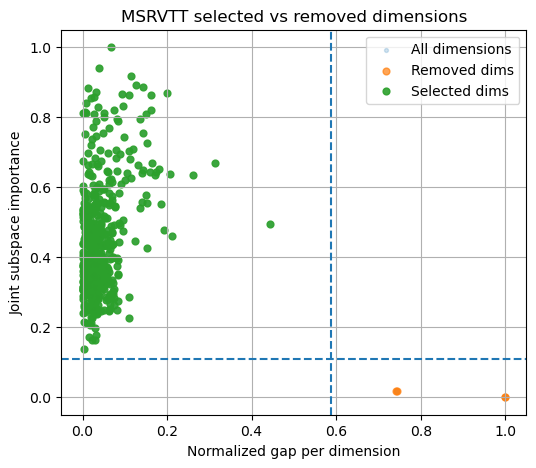

In [5]:
def eval_thresholds_msrvtt(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    important_joint_dims,
    gap_dims,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = select_dims(
        important_joint_dims,
        gap_dims,
        imp_thr,
        gap_thr,
        min_dims=min_dims,
    )

    r_orig = {1: [], 5: [], 10: []}
    r_aligned = {1: [], 5: [], 10: []}

    gaps_orig_batches = {g: [] for g in GAP_NAMES}
    gaps_aligned_batches = {g: [] for g in GAP_NAMES}

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="MSRVTT threshold evaluation", leave=False):
            text_b, vis_b, labels = batch[:3]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X
            elif direction != "text_to_vision":
                raise ValueError(f"Unknown direction: {direction}")

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=1)))
            r_orig[5].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=5)))
            r_orig[10].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=10)))

            Xn, _, Yaln = apply_subspace_alignment(X, Y, sub_model)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_aligned[1].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=1)))
            r_aligned[5].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=5)))
            r_aligned[10].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=10)))

            for gap_name in GAP_NAMES:
                gaps_orig_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xs, Ys, iterations=None))
                )
                gaps_aligned_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xal_s, Yal_s, iterations=None))
                )

            if labels is not None and seen < max_cluster_samples:
                labels_t = torch.as_tensor(labels)
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                labels_buf.append(labels_t[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    clustering_orig = None
    clustering_aligned = None
    if labels_buf:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        labels_all = torch.cat(labels_buf, dim=0)

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_all, labels_all, n_clusters=n_clusters
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_al_all, labels_all, n_clusters=n_clusters
        )

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_aligned.items()},
        "gaps_orig": {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()},
        "gaps_aligned": {g: float(np.mean(v)) for g, v in gaps_aligned_batches.items()},
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }
    return metrics

print("Fitting MSRVTT subspace alignment model...")
sub_model = fit_subspace_alignment(
    train_loader,
    n_fit=10_000,
    d_sub=D_SUB,
    device=DEVICE,
)

important_dims_txt, important_dims_vid, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=DEVICE,
)
gap_dims, top_gap_idx = get_dims_gap(train_loader, device=DEVICE)

# We get the thresholds from the file few_dimensions.ipynb
imp_thr = 0.1085
gap_thr = 0.5880

metrics = eval_thresholds_msrvtt(
    imp_thr=imp_thr,
    gap_thr=gap_thr,
    test_loader=test_loader,
    sub_model=sub_model,
    important_joint_dims=important_joint_dims,
    gap_dims=gap_dims,
    device=DEVICE,
    max_eval_batches=MSRVTT_SEARCH_CFG["max_eval_batches"],
    max_cluster_samples=MSRVTT_SEARCH_CFG["max_cluster_samples"],
    n_clusters=MSRVTT_SEARCH_CFG["n_clusters"],
    direction=MSRVTT_SEARCH_CFG["direction"],
    min_dims=MSRVTT_SEARCH_CFG["min_dims"],
)
r1_orig = metrics["retrieval_orig"][1]
r1_aligned = metrics["retrieval_aligned"][1]
v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
v_aligned = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0


selected_dims_msrvtt = np.asarray(metrics["dim_idx"], dtype=np.int64)
removed_dims_msrvtt = np.setdiff1d(np.arange(embedding_dim), selected_dims_msrvtt)
selected_dims_msrvtt_t = torch.as_tensor(selected_dims_msrvtt, dtype=torch.long, device=DEVICE)

dimension_search_summary = {
    "imp_thr": imp_thr,
    "gap_thr": gap_thr,
    "selected_dims": int(selected_dims_msrvtt.size),
    "removed_dims": int(removed_dims_msrvtt.size),
    "best_score": 0.5 * (r1_orig + r1_aligned) + 0.5 * (v_orig + v_aligned),
    "retrieval_orig@1": float(r1_orig),
    "retrieval_aligned@1": float(r1_aligned),
    "v_measure_orig": float(v_orig) if v_orig is not None else float("nan"),
    "v_measure_aligned": float(v_aligned) if v_aligned is not None else float("nan"),
}

print("Best MSRVTT thresholds:")
for key, value in dimension_search_summary.items():
    print(f"  {key}: {value}")

print("First 20 selected dims:", selected_dims_msrvtt[:20].tolist())
print("First 20 removed dims :", removed_dims_msrvtt[:20].tolist())

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[selected_dims_msrvtt] = False

plt.scatter(
    gap_dims[removed_mask],
    important_joint_dims[removed_mask],
    s=24,
    alpha=0.7,
    label="Removed dims",
)
plt.scatter(
    gap_dims[selected_dims_msrvtt],
    important_joint_dims[selected_dims_msrvtt],
    s=24,
    alpha=0.9,
    label="Selected dims",
)
plt.axvline(gap_thr, linestyle="--")
plt.axhline(imp_thr, linestyle="--")
plt.xlabel("Normalized gap per dimension")
plt.ylabel("Joint subspace importance")
plt.title("MSRVTT selected vs removed dimensions")
plt.grid(True)
plt.legend()
plt.show()

In [6]:
def make_optimizer_and_scheduler(model, train_loader, epochs=20, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e4,
        anneal_strategy="cos",
    )
    return optimizer, scheduler

def remap_labels(labels_gpu: torch.Tensor, lut_gpu: torch.Tensor) -> torch.Tensor:
    if labels_gpu.numel() == 0:
        return labels_gpu

    if labels_gpu.min().item() < 0 or labels_gpu.max().item() >= lut_gpu.numel():
        raise ValueError(
            f"Labels out of LUT range. min={labels_gpu.min().item()} max={labels_gpu.max().item()} lut_size={lut_gpu.numel()}"
        )

    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].detach().cpu().numpy()
        raise ValueError(f"Found labels missing from the train label map. Examples: {bad}")
    return mapped

def prepare_features_for_scenario(
    text_emb,
    vision_emb,
    scenario_mode,
    selected_dims=None,
    sub_model=None,
    device="cuda",
):
    if scenario_mode == "baseline":
        return text_emb, vision_emb

    if selected_dims is None:
        raise ValueError("selected_dims must be provided for the filtered scenarios.")

    if scenario_mode == "original_filtered":
        return (
            text_emb.index_select(dim=1, index=selected_dims),
            vision_emb.index_select(dim=1, index=selected_dims),
        )

    if scenario_mode == "aligned_filtered":
        if sub_model is None:
            raise ValueError("sub_model must be provided for the aligned scenario.")
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return (
            X_al.index_select(dim=1, index=selected_dims),
            Y_al.index_select(dim=1, index=selected_dims),
        )

    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")

def train_linear_probe_msrvtt_independent(
    scenario_name,
    scenario_mode,
    train_loader,
    test_loader,
    num_classes,
    feature_dim,
    device="cuda",
    selected_dims=None,
    sub_model=None,
    epochs=200,
    patience=20,
    max_lr=3e-4,
    weight_decay=1e-4,
    wandb_enabled=True,
    wandb_project="msrvtt_clip_classifier",
    wandb_group="msrvtt_linear_probe_subspace",
    extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbingIndependentModalities(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model,
        train_loader,
        epochs=epochs,
        max_lr=max_lr,
        weight_decay=weight_decay,
    )

    lut_gpu = label_lut_cpu.to(device)
    selected_dims_t = None
    if selected_dims is not None:
        selected_dims_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device)

    run = None
    run_config = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "num_classes": int(num_classes),
        "epochs": int(epochs),
        "patience": int(patience),
        "max_lr": float(max_lr),
        "weight_decay": float(weight_decay),
        "d_sub": int(D_SUB),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
        "independent_modalities": True,
    }
    if extra_config is not None:
        run_config.update(extra_config)

    if wandb_enabled:
        run = wandb.init(
            project=wandb_project,
            group=wandb_group,
            name=scenario_name,
            config=run_config,
            reinit=True,
        )

    history = {
        "train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
        "test": {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}},
    }

    best_test_loss = float("inf")
    best_test_acc = 0.0
    best_loss_state = None
    best_acc_state = None
    epochs_no_improve = 0

    def run_epoch(dataloader, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()

        losses, accs, lrs = [], [], []
        gap_values = {g: [] for g in GAP_NAMES}

        iterator = tqdm(dataloader, desc=f"{scenario_name} | {phase}", leave=False)
        for batch in iterator:
            text_emb, vision_emb, labels = batch[:3]

            text_emb = text_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            vision_emb = vision_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            labels = torch.as_tensor(labels, device=device, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb,
                vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=selected_dims_t,
                sub_model=sub_model,
                device=device,
            )

            # ── Independent-modality: each modality is its own sample ──
            # Stack text and vision into one batch of 2*B independent samples
            all_emb = torch.cat([text_feat, vision_feat], dim=0)     # (2B, d)
            all_labels = torch.cat([labels, labels], dim=0)          # (2B,)

            logits = model(all_emb)                                  # (2B, C)
            loss = criterion(logits, all_labels)

            if is_train:
                loss.backward()
                clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            acc = (logits.argmax(dim=1) == all_labels).float().mean()

            losses.append(float(loss.item()))
            accs.append(float(acc.item()))
            if is_train:
                lrs.append(float(optimizer.param_groups[0]["lr"]))

            with torch.no_grad():
                text_det = text_feat.detach()
                vision_det = vision_feat.detach()
                for gap_name in GAP_NAMES:
                    gap_values[gap_name].append(
                        gap_to_float(compute_gap(gap_name, text_det, vision_det, iterations=None))
                    )

        mean_loss = float(np.mean(losses)) if losses else float("nan")
        mean_acc = float(np.mean(accs)) if accs else float("nan")
        mean_lr = float(np.mean(lrs)) if (is_train and lrs) else None
        mean_gaps = {gap_name: float(np.mean(values)) for gap_name, values in gap_values.items()}

        return mean_loss, mean_acc, mean_lr, mean_gaps

    for epoch in range(epochs):
        train_loss, train_acc, train_lr, train_gaps = run_epoch(train_loader, phase="train")
        with torch.no_grad():
            test_loss, test_acc, _, test_gaps = run_epoch(test_loader, phase="test")

        history["train"]["loss"].append(train_loss)
        history["train"]["accuracy"].append(train_acc)
        history["train"]["lr"].append(train_lr if train_lr is not None else float("nan"))
        for gap_name in GAP_NAMES:
            history["train"][gap_name].append(train_gaps[gap_name])

        history["test"]["loss"].append(test_loss)
        history["test"]["accuracy"].append(test_acc)
        for gap_name in GAP_NAMES:
            history["test"][gap_name].append(test_gaps[gap_name])

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"[{scenario_name}] epoch {epoch + 1}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

        improved = False

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_loss_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_loss",
                    "metric_value": best_test_loss,
                    "model_state_dict": best_loss_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_loss.pt",
            )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_acc_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_accuracy",
                    "metric_value": best_test_acc,
                    "model_state_dict": best_acc_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_acc.pt",
            )

        if improved:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if run is not None:
            payload = {
                "epoch": epoch + 1,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "train/lr": train_lr,
                "test/loss": test_loss,
                "test/accuracy": test_acc,
                "best/test_loss": best_test_loss,
                "best/test_accuracy": best_test_acc,
                "early_stop/epochs_no_improve": epochs_no_improve,
            }
            for gap_name in GAP_NAMES:
                payload[f"train/{gap_name}"] = train_gaps[gap_name]
                payload[f"test/{gap_name}"] = test_gaps[gap_name]
            wandb.log(payload)

        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch + 1} / {epochs}")
            break

    if best_acc_state is not None:
        model.load_state_dict(best_acc_state)
        best_checkpoint_metric = "test_accuracy"
    elif best_loss_state is not None:
        model.load_state_dict(best_loss_state)
        best_checkpoint_metric = "test_loss"
    else:
        best_checkpoint_metric = "last_epoch"

    with torch.no_grad():
        final_train_loss, final_train_acc, _, final_train_gaps = run_epoch(train_loader, phase="test")
        final_test_loss, final_test_acc, _, final_test_gaps = run_epoch(test_loader, phase="test")

    result = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
        "removed_dims_count": int(embedding_dim - len(selected_dims)) if selected_dims is not None else 0,
        "best_checkpoint_metric": best_checkpoint_metric,
        "best_test_loss": float(best_test_loss),
        "best_test_acc": float(best_test_acc),
        "final_train_loss": float(final_train_loss),
        "final_train_acc": float(final_train_acc),
        "final_test_loss": float(final_test_loss),
        "final_test_acc": float(final_test_acc),
        "final_train_gaps": {k: float(v) for k, v in final_train_gaps.items()},
        "final_test_gaps": {k: float(v) for k, v in final_test_gaps.items()},
        "history": history,
        "checkpoint_dir": str(scenario_dir),
    }

    with open(scenario_dir / "summary.json", "w") as f:
        json.dump(result, f, indent=2)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "result": result,
            "config": run_config,
        },
        scenario_dir / "best_model_loaded_final.pt",
    )

    if run is not None:
        run.summary["best_test_loss"] = result["best_test_loss"]
        run.summary["best_test_acc"] = result["best_test_acc"]
        run.summary["final_train_acc"] = result["final_train_acc"]
        run.summary["final_test_acc"] = result["final_test_acc"]
        run.summary["selected_dims_count"] = result["selected_dims_count"]
        run.summary["removed_dims_count"] = result["removed_dims_count"]
        for gap_name in GAP_NAMES:
            run.summary[f"final_train_{gap_name}"] = result["final_train_gaps"][gap_name]
            run.summary[f"final_test_{gap_name}"] = result["final_test_gaps"][gap_name]
        run.finish()

    print(
        f"[{scenario_name}] done | best_test_acc={result['best_test_acc']:.4f} | "
        f"final_test_acc={result['final_test_acc']:.4f}"
    )
    return result

def build_summary_table(results_dict):
    rows = []
    for scenario_name, result in results_dict.items():
        row = {
            "scenario": scenario_name,
            "feature_dim": result["feature_dim"],
            "selected_dims": result["selected_dims_count"],
            "removed_dims": result["removed_dims_count"],
            "best_test_acc": result["best_test_acc"],
            "best_test_loss": result["best_test_loss"],
            "final_train_acc": result["final_train_acc"],
            "final_test_acc": result["final_test_acc"],
            "final_train_loss": result["final_train_loss"],
            "final_test_loss": result["final_test_loss"],
        }
        for gap_name in GAP_NAMES:
            row[f"train_{gap_name}"] = result["final_train_gaps"][gap_name]
            row[f"test_{gap_name}"] = result["final_test_gaps"][gap_name]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)

def plot_metric_history(results_dict, split, metric, title):
    plt.figure(figsize=(8, 5))
    for scenario_name, result in results_dict.items():
        plt.plot(result["history"][split][metric], label=scenario_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_final_metric_bars(summary_df, metric, title):
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["scenario"], summary_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.show()

scenario_results = {}

### Baseline
Train the classifier on the original clip embeddings concatenated.

In [7]:
scenario_results["msrvtt_s1_full_original_ind"] = train_linear_probe_msrvtt_independent(
    scenario_name="msrvtt_s1_full_original_ind",
    scenario_mode="baseline",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=embedding_dim,
    device=DEVICE,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "none",
        "notes": "Linear probe on the original full MSRVTT embeddings.",
    },
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/emanuele/.netrc.
wandb: Currently logged in as: rucci-emanuele (rucci-emanuele-personal) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


[msrvtt_s1_full_original_ind] epoch 1/200 | train_loss=2.9906 train_acc=0.0609 | test_loss=2.9890 test_acc=0.0661


[msrvtt_s1_full_original_ind] epoch 11/200 | train_loss=2.7435 train_acc=0.4269 | test_loss=2.7192 test_acc=0.4293


[msrvtt_s1_full_original_ind] epoch 21/200 | train_loss=2.2387 train_acc=0.5096 | test_loss=2.2317 test_acc=0.5175


[msrvtt_s1_full_original_ind] epoch 31/200 | train_loss=1.9541 train_acc=0.5608 | test_loss=1.9774 test_acc=0.5731


...

[msrvtt_s1_full_original_ind] epoch 171/200 | train_loss=1.5546 train_acc=0.6549 | test_loss=1.7441 test_acc=0.6069


[msrvtt_s1_full_original_ind] early stop at epoch 177 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▃▄▅▆▇██████████████████████████████████
best/test_loss,███▇▄▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▂▄▅█
epoch,▁▁▁▁▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇█████
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▂▄▅▆▆▇▇▇▇▇█████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,████▆▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s1_full_original_ind] done | best_test_acc=0.6102 | final_test_acc=0.6102


### Original space subdimensions

In [8]:
scenario_results["msrvtt_s2_original_filtered_ind"] = train_linear_probe_msrvtt_independent(
    scenario_name="msrvtt_s2_original_filtered_ind",
    scenario_mode="original_filtered",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=int(len(selected_dims_msrvtt)),
    device=DEVICE,
    selected_dims=selected_dims_msrvtt,
    sub_model=None,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_threshold_search",
        "imp_thr": imp_thr,
        "gap_thr": gap_thr,
        "notes": "Independent modalities linear probe on the original MSRVTT embeddings after removing the dimensions discarded by the subspace-based selector.",
    },
)

[msrvtt_s2_original_filtered_ind] epoch 1/200 | train_loss=2.9941 train_acc=0.0479 | test_loss=2.9926 test_acc=0.0533


[msrvtt_s2_original_filtered_ind] epoch 11/200 | train_loss=2.7540 train_acc=0.4490 | test_loss=2.7294 test_acc=0.4598


[msrvtt_s2_original_filtered_ind] epoch 21/200 | train_loss=2.2451 train_acc=0.5131 | test_loss=2.2363 test_acc=0.5224


[msrvtt_s2_original_filtered_ind] epoch 31/200 | train_loss=1.9585 train_acc=0.5601 | test_loss=1.9800 test_acc=0.5749


[msrvtt_s2_original_filtered_ind] epoch 41/200 | train_loss=1.8196 train_acc=0.5851 | test_loss=1.8652 test_acc=0.5914


...

[msrvtt_s2_original_filtered_ind] epoch 171/200 | train_loss=1.5555 train_acc=0.6546 | test_loss=1.7430 test_acc=0.6079


[msrvtt_s2_original_filtered_ind] epoch 181/200 | train_loss=1.5548 train_acc=0.6554 | test_loss=1.7430 test_acc=0.6079
[msrvtt_s2_original_filtered_ind] early stop at epoch 181 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▂▅▆▆▇▇█████████████████████████████████
best/test_loss,██▇▆▆▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▄▂▅▅▆█
epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇▇▇▇███
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▁▂▆▆▇██████████████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,███▇▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s2_original_filtered_ind] done | best_test_acc=0.6089 | final_test_acc=0.6089


### Aligned space subdimensions

In [9]:
scenario_results["msrvtt_s3_aligned_filtered_ind"] = train_linear_probe_msrvtt_independent(
    scenario_name="msrvtt_s3_aligned_filtered_ind",
    scenario_mode="aligned_filtered",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=int(len(selected_dims_msrvtt)),
    device=DEVICE,
    selected_dims=selected_dims_msrvtt,
    sub_model=sub_model,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "few_dimensions_msrvtt_threshold_search",
        "imp_thr": imp_thr,
        "gap_thr": gap_thr,
        "notes": "Independent modalities linear probe on the aligned MSRVTT embeddings after removing the dimensions discarded by the subspace-based selector.",
    },
)

[msrvtt_s3_aligned_filtered_ind] epoch 1/200 | train_loss=2.9957 train_acc=0.0588 | test_loss=2.9923 test_acc=0.0794


[msrvtt_s3_aligned_filtered_ind] epoch 11/200 | train_loss=2.7432 train_acc=0.4249 | test_loss=2.7143 test_acc=0.4402


[msrvtt_s3_aligned_filtered_ind] epoch 21/200 | train_loss=2.2316 train_acc=0.5128 | test_loss=2.2148 test_acc=0.5256


[msrvtt_s3_aligned_filtered_ind] epoch 31/200 | train_loss=1.9536 train_acc=0.5576 | test_loss=1.9627 test_acc=0.5641


[msrvtt_s3_aligned_filtered_ind] epoch 41/200 | train_loss=1.8263 train_acc=0.5760 | test_loss=1.8565 test_acc=0.5826


...

[msrvtt_s3_aligned_filtered_ind] epoch 161/200 | train_loss=1.6121 train_acc=0.6304 | test_loss=1.7572 test_acc=0.6071


[msrvtt_s3_aligned_filtered_ind] early stop at epoch 163 / 200


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


best/test_accuracy,▁▃▄▅▅▆▆▇▇▇▇▇▇███████████████████████████
best/test_loss,███▇▇▅▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
early_stop/epochs_no_improve,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▃▃▄▅█
epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇█████
test/L2I,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/L2M,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/RMG,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁▄▅▆▆▆▆▇▇▇▇▇▇███████████████████████████
test/cosineTP,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/loss,█▆▅▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+7,...


[msrvtt_s3_aligned_filtered_ind] done | best_test_acc=0.6076 | final_test_acc=0.6076


### EXP recap

,scenario,feature_dim,selected_dims,removed_dims,best_test_acc,best_test_loss,final_train_acc,final_test_acc,final_train_loss,final_test_loss,train_RMG,test_RMG,train_L2M,test_L2M,train_L2I,test_L2I,train_cosineTP,test_cosineTP
0,msrvtt_s1_full_original_ind,512,512,0,0.610220,1.744036,0.646109,0.610220,1.578917,1.745259,0.836980,0.837280,0.776554,0.778526,1.201227,1.199774,0.277460,0.279267
1,msrvtt_s2_original_filtered_ind,508,508,4,0.608876,1.742968,0.653939,0.608876,1.556836,1.742985,0.790840,0.791471,0.480819,0.486786,1.019272,1.018157,0.276874,0.279003
2,msrvtt_s3_aligned_filtered_ind,508,508,4,0.607595,1.756782,0.630275,0.607595,1.615561,1.756955,0.736941,0.737057,0.056950,0.065420,0.817570,0.813980,0.459270,0.462691


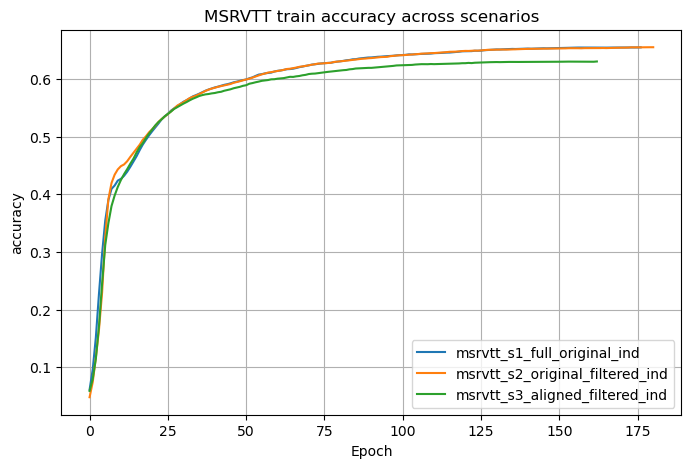

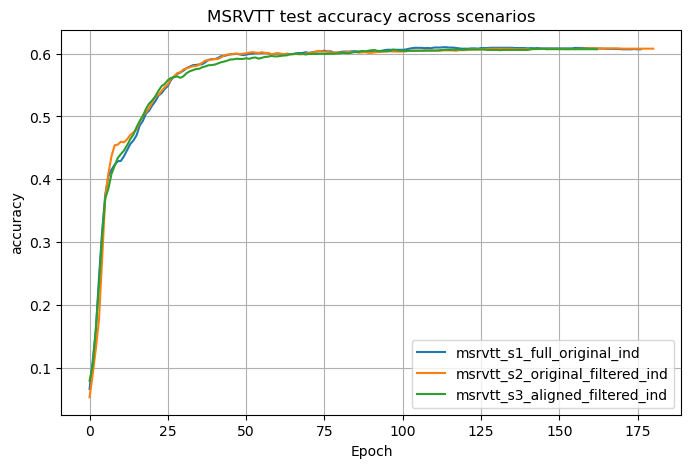

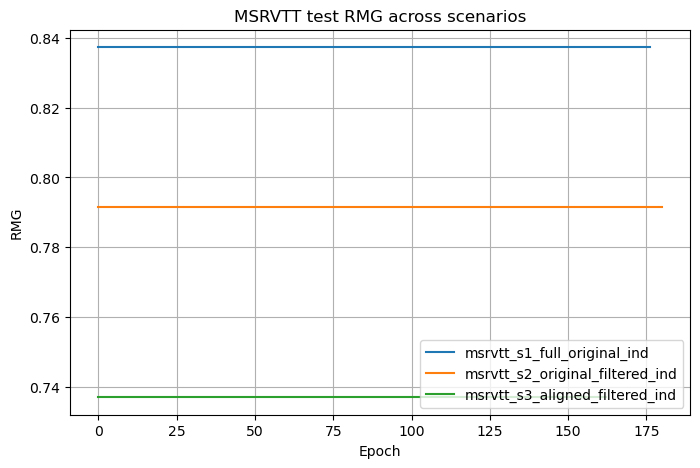

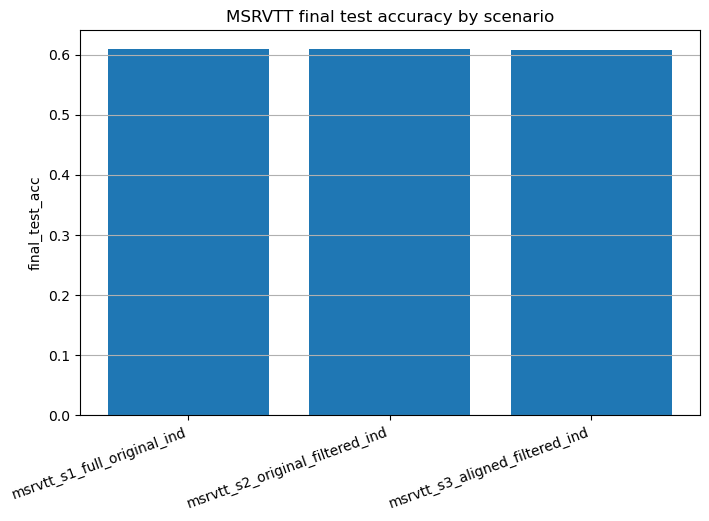

In [10]:
summary_df_msrvtt = build_summary_table(scenario_results)
display(summary_df_msrvtt)

plot_metric_history(
    scenario_results,
    split="train",
    metric="accuracy",
    title="MSRVTT train accuracy across scenarios",
)
plot_metric_history(
    scenario_results,
    split="test",
    metric="accuracy",
    title="MSRVTT test accuracy across scenarios",
)
plot_metric_history(
    scenario_results,
    split="test",
    metric="RMG",
    title="MSRVTT test RMG across scenarios",
)
plot_final_metric_bars(
    summary_df_msrvtt,
    metric="final_test_acc",
    title="MSRVTT final test accuracy by scenario",
)

### Run the models on the test set and get the values (loss and accuracy)

In [ ]:
import json
from pathlib import Path

# ── Scenario configs: name → (scenario_mode, feature_dim, selected_dims, sub_model) ──
scenario_configs = {
    "msrvtt_s1_full_original_ind": ("baseline", embedding_dim, None, None),
    "msrvtt_s2_original_filtered_ind": ("original_filtered", int(len(selected_dims_msrvtt)), selected_dims_msrvtt, None),
    "msrvtt_s3_aligned_filtered_ind": ("aligned_filtered", int(len(selected_dims_msrvtt)), selected_dims_msrvtt, sub_model),
}

lut_gpu = label_lut_cpu.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(DEVICE)

eval_results = {}

for scenario_name, (scenario_mode, feat_dim, sel_dims, s_model) in scenario_configs.items():
    ckpt_path = BASE_SAVE_DIR / scenario_name / "best_model_test_acc.pt"
    if not ckpt_path.exists():
        print(f"[{scenario_name}] checkpoint not found at {ckpt_path}, skipping.")
        continue

    # Load checkpoint — independent modalities model (nn.Linear(d, C))
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model = LinearProbingIndependentModalities(d=feat_dim, num_classes=num_classes).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    sel_dims_t = None
    if sel_dims is not None:
        sel_dims_t = torch.as_tensor(sel_dims, dtype=torch.long, device=DEVICE)

    # Evaluate on test set — each modality is an independent sample
    losses, accs = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Eval {scenario_name}", leave=False):
            text_emb, vision_emb, labels = batch[:3]
            text_emb = text_emb.to(device=DEVICE, dtype=torch.float32)
            vision_emb = vision_emb.to(device=DEVICE, dtype=torch.float32)
            labels = torch.as_tensor(labels, device=DEVICE, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb, vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=sel_dims_t,
                sub_model=s_model,
                device=DEVICE,
            )

            # Independent modalities: 2*B forward passes
            all_emb = torch.cat([text_feat, vision_feat], dim=0)     # (2B, d)
            all_labels = torch.cat([labels, labels], dim=0)          # (2B,)

            logits = model(all_emb)                                  # (2B, C)
            loss = criterion(logits, all_labels)
            acc = (logits.argmax(dim=1) == all_labels).float().mean()

            losses.append(loss.item())
            accs.append(acc.item())

    test_loss = float(np.mean(losses))
    test_acc = float(np.mean(accs))
    eval_results[scenario_name] = {
        "test_loss": test_loss,
        "test_acc": test_acc,
        "ckpt_epoch": ckpt.get("epoch", "?"),
        "feature_dim": feat_dim,
    }
    print(f"[{scenario_name}] test_loss={test_loss:.4f}  test_acc={test_acc:.4f}  (ckpt epoch {ckpt.get('epoch', '?')})")

# ── Summary table ──
print("\n" + "=" * 80)
print(f"{'Scenario':<40s} {'Test Loss':>10s} {'Test Acc':>10s} {'Feat Dim':>10s}")
print("-" * 80)
for name, res in eval_results.items():
    print(f"{name:<40s} {res['test_loss']:>10.4f} {res['test_acc']:>10.4f} {res['feature_dim']:>10d}")
print("=" * 80)

[msrvtt_s1_full_original_ind] test_loss=1.7453  test_acc=0.6102  (ckpt epoch 114)


[msrvtt_s2_original_filtered_ind] test_loss=1.7430  test_acc=0.6089  (ckpt epoch 161)


Eval msrvtt_s3_aligned_filtered_ind:   0%|          | 0/2 [00:00<?, ?it/s]

[msrvtt_s3_aligned_filtered_ind] test_loss=1.7570  test_acc=0.6076  (ckpt epoch 143)

Scenario                                  Test Loss   Test Acc   Feat Dim
--------------------------------------------------------------------------------
msrvtt_s1_full_original_ind                  1.7453     0.6102        512
msrvtt_s2_original_filtered_ind              1.7430     0.6089        508
msrvtt_s3_aligned_filtered_ind               1.7570     0.6076        508


: 

## MSRVTT ind. mod. non linear classifier
We do not observe any improvement over the classification task even if we improve the clustering and we are able match the retrieval. This yields to the hypotesis that a better space exists after alignment but a linear layer is not able to apreciate such benefit. So here we try to use a non linear model to check if here works

### Shared code

In [ ]:
import copy
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

try:
    import wandb
except ImportError as exc:
    raise ImportError("wandb is required for this notebook. Install it with `pip install wandb`.") from exc

try:
    import optuna
except ImportError as exc:
    raise ImportError("optuna is required for the MSRVTT dimension search. Install it with `pip install optuna`.") from exc

sys.path.append(os.path.abspath(".."))

from dataset.msrvtt.msrvtt_dataloader import (
    MSRVTTEmbeddingsDataset,
    msrvtt_collate_fn,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt
from models.fusion_mlp_classifier import NonLinearProbingIndependentModalities


SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if hasattr(torch, "set_float32_matmul_precision"):
    torch.set_float32_matmul_precision("high")

DEVICE = os.environ.get("MSRVTT_CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

PRECOMPUTED_TRAIN_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_train"
PRECOMPUTED_TEST_DIR = "/mnt/media/emanuele/few_dimensions/dataset/msrvtt/ViT-B-32___laion2b_s34b_b79k/precomputed_test"

ALLOW_MULTI_CAPTION = True
TEXT_INDEX = 0
BATCH_SIZE = 512
NUM_WORKERS = 0

D_SUB = 256
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4

WANDB_ENABLED = True
WANDB_PROJECT = "msrvtt_clip_classifier"
WANDB_GROUP = "msrvtt_linear_probe_subspace"

BASE_SAVE_DIR = Path("msrvtt_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

MSRVTT_SEARCH_CFG = {
    "n_trials": 100,
    "seed": 0,
    "max_eval_batches": 40,
    "max_cluster_samples": 3000,
    "min_dims": 16,
    "direction": "text_to_vision",
    "n_clusters": 20,
}

In [ ]:
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)

def extract_labels_from_dataset(dataset, desc="labels"):
    labels = []
    for idx in tqdm(range(len(dataset)), desc=desc):
        item = dataset[idx]
        if len(item) < 3:
            raise ValueError("MSRVTT dataset is expected to return at least (text, vision, label).")
        labels.append(label_to_int(item[2]))
    return np.asarray(labels, dtype=np.int64)

def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b = F.normalize(vis_b.to(device), dim=-1).cpu().numpy()

            Xs.append(text_b)
            Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break

    X = np.concatenate(Xs, axis=0)[:max_samples]
    Y = np.concatenate(Ys, axis=0)[:max_samples]

    mu_x = X.mean(axis=0)
    mu_y = Y.mean(axis=0)

    gap_dim = np.abs(mu_x - mu_y)
    top_gap = np.argsort(-gap_dim)
    return normalize01(gap_dim), top_gap

def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-importance)
        idx = order[:min_dims]
    return np.sort(idx)

ds_train = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TRAIN_DIR,
    split_name="train_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

ds_test = MSRVTTEmbeddingsDataset(
    PRECOMPUTED_TEST_DIR,
    split_name="test_shard",
    allow_multi_caption=ALLOW_MULTI_CAPTION,
    text_index=TEXT_INDEX,
    return_metadata=False,
)

train_loader = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

test_loader = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
    collate_fn=msrvtt_collate_fn,
)

embedding_dim = int(ds_train[0][0].shape[-1])
num_classes = len(set(extract_labels_from_dataset(ds_train, desc="Extracting train labels")))
label_lut_cpu = {label: idx for idx, label in enumerate(sorted(set(extract_labels_from_dataset(ds_train, desc="Building label LUT"))))}
label_lut_cpu = torch.Tensor([label_lut_cpu[label] for label in sorted(label_lut_cpu.keys())])
# convert to int for later use
label_lut_cpu = label_lut_cpu.long()

print(f"Train samples: {len(ds_train)}")
print(f"Test samples : {len(ds_test)}")
print(f"Number of classes: {num_classes}")
print(f"Embedding dimension: {embedding_dim}")

In [ ]:
def eval_thresholds_msrvtt(
    imp_thr,
    gap_thr,
    test_loader,
    sub_model,
    important_joint_dims,
    gap_dims,
    device="cuda",
    max_eval_batches=None,
    max_cluster_samples=3000,
    n_clusters=20,
    direction="text_to_vision",
    min_dims=16,
):
    idx = select_dims(
        important_joint_dims,
        gap_dims,
        imp_thr,
        gap_thr,
        min_dims=min_dims,
    )

    r_orig = {1: [], 5: [], 10: []}
    r_aligned = {1: [], 5: [], 10: []}

    gaps_orig_batches = {g: [] for g in GAP_NAMES}
    gaps_aligned_batches = {g: [] for g in GAP_NAMES}

    Xt_buf, Xv_buf, Xv_al_buf, labels_buf = [], [], [], []
    seen = 0
    n_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="MSRVTT threshold evaluation", leave=False):
            text_b, vis_b, labels = batch[:3]

            X = F.normalize(text_b.to(device), dim=-1)
            Y = F.normalize(vis_b.to(device), dim=-1)

            if direction == "vision_to_text":
                X, Y = Y, X
            elif direction != "text_to_vision":
                raise ValueError(f"Unknown direction: {direction}")

            Xs = X[:, idx]
            Ys = Y[:, idx]

            r_orig[1].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=1)))
            r_orig[5].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=5)))
            r_orig[10].append(gap_to_float(compute_retrieval("msrvtt", (Xs, Ys), top_k=10)))

            Xn, _, Yaln = apply_subspace_alignment(X, Y, sub_model)
            Xal_s = Xn[:, idx]
            Yal_s = Yaln[:, idx]

            r_aligned[1].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=1)))
            r_aligned[5].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=5)))
            r_aligned[10].append(gap_to_float(compute_retrieval("msrvtt", (Xal_s, Yal_s), top_k=10)))

            for gap_name in GAP_NAMES:
                gaps_orig_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xs, Ys, iterations=None))
                )
                gaps_aligned_batches[gap_name].append(
                    gap_to_float(compute_gap(gap_name, Xal_s, Yal_s, iterations=None))
                )

            if labels is not None and seen < max_cluster_samples:
                labels_t = torch.as_tensor(labels)
                b = min(Xs.shape[0], max_cluster_samples - seen)
                Xt_buf.append(Xs[:b].detach().cpu())
                Xv_buf.append(Ys[:b].detach().cpu())
                Xv_al_buf.append(Yal_s[:b].detach().cpu())
                labels_buf.append(labels_t[:b].detach().cpu())
                seen += b

            n_batches += 1
            if max_eval_batches is not None and n_batches >= max_eval_batches:
                break

    clustering_orig = None
    clustering_aligned = None
    if labels_buf:
        Xt_all = torch.cat(Xt_buf, dim=0)
        Xv_all = torch.cat(Xv_buf, dim=0)
        Xv_al_all = torch.cat(Xv_al_buf, dim=0)
        labels_all = torch.cat(labels_buf, dim=0)

        clustering_orig = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_all, labels_all, n_clusters=n_clusters
        )
        clustering_aligned = clustering_metrics_two_modalities_msrvtt(
            Xt_all, Xv_al_all, labels_all, n_clusters=n_clusters
        )

    metrics = {
        "n_dims": int(idx.size),
        "dim_idx": idx,
        "retrieval_orig": {k: float(np.mean(v)) for k, v in r_orig.items()},
        "retrieval_aligned": {k: float(np.mean(v)) for k, v in r_aligned.items()},
        "gaps_orig": {g: float(np.mean(v)) for g, v in gaps_orig_batches.items()},
        "gaps_aligned": {g: float(np.mean(v)) for g, v in gaps_aligned_batches.items()},
        "clustering_orig": clustering_orig,
        "clustering_aligned": clustering_aligned,
    }
    return metrics

print("Fitting MSRVTT subspace alignment model...")
sub_model = fit_subspace_alignment(
    train_loader,
    n_fit=10_000,
    d_sub=D_SUB,
    device=DEVICE,
)

important_dims_txt, important_dims_vid, important_joint_dims = analyze_subspace_dimensions(
    sub_model,
    device=DEVICE,
)
gap_dims, top_gap_idx = get_dims_gap(train_loader, device=DEVICE)

# We get the thresholds from the file few_dimensions.ipynb
imp_thr = 0.1085
gap_thr = 0.5880

metrics = eval_thresholds_msrvtt(
    imp_thr=imp_thr,
    gap_thr=gap_thr,
    test_loader=test_loader,
    sub_model=sub_model,
    important_joint_dims=important_joint_dims,
    gap_dims=gap_dims,
    device=DEVICE,
    max_eval_batches=MSRVTT_SEARCH_CFG["max_eval_batches"],
    max_cluster_samples=MSRVTT_SEARCH_CFG["max_cluster_samples"],
    n_clusters=MSRVTT_SEARCH_CFG["n_clusters"],
    direction=MSRVTT_SEARCH_CFG["direction"],
    min_dims=MSRVTT_SEARCH_CFG["min_dims"],
)
r1_orig = metrics["retrieval_orig"][1]
r1_aligned = metrics["retrieval_aligned"][1]
v_orig = metrics["clustering_orig"]["V-measure"] if metrics["clustering_orig"] else 0.0
v_aligned = metrics["clustering_aligned"]["V-measure"] if metrics["clustering_aligned"] else 0.0


selected_dims_msrvtt = np.asarray(metrics["dim_idx"], dtype=np.int64)
removed_dims_msrvtt = np.setdiff1d(np.arange(embedding_dim), selected_dims_msrvtt)
selected_dims_msrvtt_t = torch.as_tensor(selected_dims_msrvtt, dtype=torch.long, device=DEVICE)

dimension_search_summary = {
    "imp_thr": imp_thr,
    "gap_thr": gap_thr,
    "selected_dims": int(selected_dims_msrvtt.size),
    "removed_dims": int(removed_dims_msrvtt.size),
    "best_score": 0.5 * (r1_orig + r1_aligned) + 0.5 * (v_orig + v_aligned),
    "retrieval_orig@1": float(r1_orig),
    "retrieval_aligned@1": float(r1_aligned),
    "v_measure_orig": float(v_orig) if v_orig is not None else float("nan"),
    "v_measure_aligned": float(v_aligned) if v_aligned is not None else float("nan"),
}

print("Best MSRVTT thresholds:")
for key, value in dimension_search_summary.items():
    print(f"  {key}: {value}")

print("First 20 selected dims:", selected_dims_msrvtt[:20].tolist())
print("First 20 removed dims :", removed_dims_msrvtt[:20].tolist())

plt.figure(figsize=(6, 5))
plt.scatter(gap_dims, important_joint_dims, s=8, alpha=0.2, label="All dimensions")

removed_mask = np.ones_like(gap_dims, dtype=bool)
removed_mask[selected_dims_msrvtt] = False

plt.scatter(
    gap_dims[removed_mask],
    important_joint_dims[removed_mask],
    s=24,
    alpha=0.7,
    label="Removed dims",
)
plt.scatter(
    gap_dims[selected_dims_msrvtt],
    important_joint_dims[selected_dims_msrvtt],
    s=24,
    alpha=0.9,
    label="Selected dims",
)
plt.axvline(gap_thr, linestyle="--")
plt.axhline(imp_thr, linestyle="--")
plt.xlabel("Normalized gap per dimension")
plt.ylabel("Joint subspace importance")
plt.title("MSRVTT selected vs removed dimensions")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
def make_optimizer_and_scheduler(model, train_loader, epochs=20, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=max_lr,
        epochs=epochs,
        steps_per_epoch=len(train_loader),
        pct_start=0.1,
        div_factor=25.0,
        final_div_factor=1e4,
        anneal_strategy="cos",
    )
    return optimizer, scheduler

def remap_labels(labels_gpu: torch.Tensor, lut_gpu: torch.Tensor) -> torch.Tensor:
    if labels_gpu.numel() == 0:
        return labels_gpu

    if labels_gpu.min().item() < 0 or labels_gpu.max().item() >= lut_gpu.numel():
        raise ValueError(
            f"Labels out of LUT range. min={labels_gpu.min().item()} max={labels_gpu.max().item()} lut_size={lut_gpu.numel()}"
        )

    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].detach().cpu().numpy()
        raise ValueError(f"Found labels missing from the train label map. Examples: {bad}")
    return mapped

def prepare_features_for_scenario(
    text_emb,
    vision_emb,
    scenario_mode,
    selected_dims=None,
    sub_model=None,
    device="cuda",
):
    if scenario_mode == "baseline":
        return text_emb, vision_emb

    if selected_dims is None:
        raise ValueError("selected_dims must be provided for the filtered scenarios.")

    if scenario_mode == "original_filtered":
        return (
            text_emb.index_select(dim=1, index=selected_dims),
            vision_emb.index_select(dim=1, index=selected_dims),
        )

    if scenario_mode == "aligned_filtered":
        if sub_model is None:
            raise ValueError("sub_model must be provided for the aligned scenario.")
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return (
            X_al.index_select(dim=1, index=selected_dims),
            Y_al.index_select(dim=1, index=selected_dims),
        )

    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")

def train_nonlinear_probe_msrvtt_independent(
    scenario_name,
    scenario_mode,
    train_loader,
    test_loader,
    num_classes,
    feature_dim,
    device="cuda",
    selected_dims=None,
    sub_model=None,
    epochs=200,
    patience=20,
    max_lr=3e-4,
    weight_decay=1e-4,
    wandb_enabled=True,
    wandb_project="msrvtt_clip_classifier",
    wandb_group="msrvtt_linear_probe_subspace",
    extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbingIndependentModalities(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(
        model,
        train_loader,
        epochs=epochs,
        max_lr=max_lr,
        weight_decay=weight_decay,
    )

    lut_gpu = label_lut_cpu.to(device)
    selected_dims_t = None
    if selected_dims is not None:
        selected_dims_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device)

    run = None
    run_config = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "num_classes": int(num_classes),
        "epochs": int(epochs),
        "patience": int(patience),
        "max_lr": float(max_lr),
        "weight_decay": float(weight_decay),
        "d_sub": int(D_SUB),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
        "independent_modalities": True,
    }
    if extra_config is not None:
        run_config.update(extra_config)

    if wandb_enabled:
        run = wandb.init(
            project=wandb_project,
            group=wandb_group,
            name=scenario_name,
            config=run_config,
            reinit=True,
        )

    history = {
        "train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
        "test": {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}},
    }

    best_test_loss = float("inf")
    best_test_acc = 0.0
    best_loss_state = None
    best_acc_state = None
    epochs_no_improve = 0

    def run_epoch(dataloader, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()

        losses, accs, lrs = [], [], []
        gap_values = {g: [] for g in GAP_NAMES}

        iterator = tqdm(dataloader, desc=f"{scenario_name} | {phase}", leave=False)
        for batch in iterator:
            text_emb, vision_emb, labels = batch[:3]

            text_emb = text_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            vision_emb = vision_emb.to(device=device, dtype=torch.float32, non_blocking=True)
            labels = torch.as_tensor(labels, device=device, dtype=torch.long)
            labels = remap_labels(labels, lut_gpu)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            text_feat, vision_feat = prepare_features_for_scenario(
                text_emb,
                vision_emb,
                scenario_mode=scenario_mode,
                selected_dims=selected_dims_t,
                sub_model=sub_model,
                device=device,
            )

            # ── Independent-modality: each modality is its own sample ──
            # Stack text and vision into one batch of 2*B independent samples
            all_emb = torch.cat([text_feat, vision_feat], dim=0)     # (2B, d)
            all_labels = torch.cat([labels, labels], dim=0)          # (2B,)

            logits = model(all_emb)                                  # (2B, C)
            loss = criterion(logits, all_labels)

            if is_train:
                loss.backward()
                clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

            acc = (logits.argmax(dim=1) == all_labels).float().mean()

            losses.append(float(loss.item()))
            accs.append(float(acc.item()))
            if is_train:
                lrs.append(float(optimizer.param_groups[0]["lr"]))

            with torch.no_grad():
                text_det = text_feat.detach()
                vision_det = vision_feat.detach()
                for gap_name in GAP_NAMES:
                    gap_values[gap_name].append(
                        gap_to_float(compute_gap(gap_name, text_det, vision_det, iterations=None))
                    )

        mean_loss = float(np.mean(losses)) if losses else float("nan")
        mean_acc = float(np.mean(accs)) if accs else float("nan")
        mean_lr = float(np.mean(lrs)) if (is_train and lrs) else None
        mean_gaps = {gap_name: float(np.mean(values)) for gap_name, values in gap_values.items()}

        return mean_loss, mean_acc, mean_lr, mean_gaps

    for epoch in range(epochs):
        train_loss, train_acc, train_lr, train_gaps = run_epoch(train_loader, phase="train")
        with torch.no_grad():
            test_loss, test_acc, _, test_gaps = run_epoch(test_loader, phase="test")

        history["train"]["loss"].append(train_loss)
        history["train"]["accuracy"].append(train_acc)
        history["train"]["lr"].append(train_lr if train_lr is not None else float("nan"))
        for gap_name in GAP_NAMES:
            history["train"][gap_name].append(train_gaps[gap_name])

        history["test"]["loss"].append(test_loss)
        history["test"]["accuracy"].append(test_acc)
        for gap_name in GAP_NAMES:
            history["test"][gap_name].append(test_gaps[gap_name])

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(
                f"[{scenario_name}] epoch {epoch + 1}/{epochs} | "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
                f"test_loss={test_loss:.4f} test_acc={test_acc:.4f}"
            )

        improved = False

        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_loss_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_loss",
                    "metric_value": best_test_loss,
                    "model_state_dict": best_loss_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_loss.pt",
            )

        if test_acc > best_test_acc:
            best_test_acc = test_acc
            best_acc_state = copy.deepcopy(model.state_dict())
            improved = True
            torch.save(
                {
                    "epoch": epoch + 1,
                    "metric": "test_accuracy",
                    "metric_value": best_test_acc,
                    "model_state_dict": best_acc_state,
                    "config": run_config,
                },
                scenario_dir / "best_model_test_acc.pt",
            )

        if improved:
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if run is not None:
            payload = {
                "epoch": epoch + 1,
                "train/loss": train_loss,
                "train/accuracy": train_acc,
                "train/lr": train_lr,
                "test/loss": test_loss,
                "test/accuracy": test_acc,
                "best/test_loss": best_test_loss,
                "best/test_accuracy": best_test_acc,
                "early_stop/epochs_no_improve": epochs_no_improve,
            }
            for gap_name in GAP_NAMES:
                payload[f"train/{gap_name}"] = train_gaps[gap_name]
                payload[f"test/{gap_name}"] = test_gaps[gap_name]
            wandb.log(payload)

        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch + 1} / {epochs}")
            break

    if best_acc_state is not None:
        model.load_state_dict(best_acc_state)
        best_checkpoint_metric = "test_accuracy"
    elif best_loss_state is not None:
        model.load_state_dict(best_loss_state)
        best_checkpoint_metric = "test_loss"
    else:
        best_checkpoint_metric = "last_epoch"

    with torch.no_grad():
        final_train_loss, final_train_acc, _, final_train_gaps = run_epoch(train_loader, phase="test")
        final_test_loss, final_test_acc, _, final_test_gaps = run_epoch(test_loader, phase="test")

    result = {
        "scenario_name": scenario_name,
        "scenario_mode": scenario_mode,
        "feature_dim": int(feature_dim),
        "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
        "removed_dims_count": int(embedding_dim - len(selected_dims)) if selected_dims is not None else 0,
        "best_checkpoint_metric": best_checkpoint_metric,
        "best_test_loss": float(best_test_loss),
        "best_test_acc": float(best_test_acc),
        "final_train_loss": float(final_train_loss),
        "final_train_acc": float(final_train_acc),
        "final_test_loss": float(final_test_loss),
        "final_test_acc": float(final_test_acc),
        "final_train_gaps": {k: float(v) for k, v in final_train_gaps.items()},
        "final_test_gaps": {k: float(v) for k, v in final_test_gaps.items()},
        "history": history,
        "checkpoint_dir": str(scenario_dir),
    }

    with open(scenario_dir / "summary.json", "w") as f:
        json.dump(result, f, indent=2)

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "result": result,
            "config": run_config,
        },
        scenario_dir / "best_model_loaded_final.pt",
    )

    if run is not None:
        run.summary["best_test_loss"] = result["best_test_loss"]
        run.summary["best_test_acc"] = result["best_test_acc"]
        run.summary["final_train_acc"] = result["final_train_acc"]
        run.summary["final_test_acc"] = result["final_test_acc"]
        run.summary["selected_dims_count"] = result["selected_dims_count"]
        run.summary["removed_dims_count"] = result["removed_dims_count"]
        for gap_name in GAP_NAMES:
            run.summary[f"final_train_{gap_name}"] = result["final_train_gaps"][gap_name]
            run.summary[f"final_test_{gap_name}"] = result["final_test_gaps"][gap_name]
        run.finish()

    print(
        f"[{scenario_name}] done | best_test_acc={result['best_test_acc']:.4f} | "
        f"final_test_acc={result['final_test_acc']:.4f}"
    )
    return result

def build_summary_table(results_dict):
    rows = []
    for scenario_name, result in results_dict.items():
        row = {
            "scenario": scenario_name,
            "feature_dim": result["feature_dim"],
            "selected_dims": result["selected_dims_count"],
            "removed_dims": result["removed_dims_count"],
            "best_test_acc": result["best_test_acc"],
            "best_test_loss": result["best_test_loss"],
            "final_train_acc": result["final_train_acc"],
            "final_test_acc": result["final_test_acc"],
            "final_train_loss": result["final_train_loss"],
            "final_test_loss": result["final_test_loss"],
        }
        for gap_name in GAP_NAMES:
            row[f"train_{gap_name}"] = result["final_train_gaps"][gap_name]
            row[f"test_{gap_name}"] = result["final_test_gaps"][gap_name]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)

def plot_metric_history(results_dict, split, metric, title):
    plt.figure(figsize=(8, 5))
    for scenario_name, result in results_dict.items():
        plt.plot(result["history"][split][metric], label=scenario_name)
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_final_metric_bars(summary_df, metric, title):
    plt.figure(figsize=(8, 5))
    plt.bar(summary_df["scenario"], summary_df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y")
    plt.show()

scenario_results = {}

### Baseline

In [ ]:
scenario_results["msrvtt_s1NL_full_original_ind"] = train_nonlinear_probe_msrvtt_independent(
    scenario_name="msrvtt_s1NL_full_original_ind",
    scenario_mode="baseline",
    train_loader=train_loader,
    test_loader=test_loader,
    num_classes=num_classes,
    feature_dim=embedding_dim,
    device=DEVICE,
    epochs=CLASSIFIER_EPOCHS,
    patience=CLASSIFIER_PATIENCE,
    max_lr=MAX_LR,
    weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project=WANDB_PROJECT,
    wandb_group=WANDB_GROUP,
    extra_config={
        "selected_dims_source": "none",
        "notes": "Non-linear probe on the original full MSRVTT embeddings.",
    },
)

---
# CIFAR-10 Classification

In [ ]:
import copy, json, os, random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, Subset
from tqdm.auto import tqdm

import wandb

sys.path.append(os.path.abspath(".."))

from dataset.cifar10.cifar10_dataloader_with_labels import (
    EmbeddingsDatasetWithLabels,
    make_loaders_cifar10,
)
from subspace_alignment.subspace_alignment import (
    fit_subspace_alignment,
    apply_subspace_alignment,
    analyze_subspace_dimensions,
)
from analysis.modality_gap import compute_gap
from metrics.retrieval import compute_retrieval
from metrics.clustering import clustering_metrics_two_modalities_msrvtt as clustering_metrics_cifar10
from models.fusion_mlp_classifier import LinearProbing, LinearProbingIndependentModalities

# ─── Seeds ───────────────────────────────────────────────────────────────────
SEED = 123
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = os.environ.get("CLS_DEVICE", "cuda:1" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ─── Paths ───────────────────────────────────────────────────────────────────
CIFAR10_TRAIN_DIR = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_train_ViT-B-32_laion2b_s34b_b79k"
CIFAR10_TEST_DIR  = "/mnt/media/emanuele/few_dimensions/dataset/cifar10/precomputed_cifar10_text_vision_labels/cifar10_test_ViT-B-32_laion2b_s34b_b79k"

BATCH_SIZE = 256
NUM_WORKERS = 0
D_SUB = 256
CLASSIFIER_EPOCHS = 200
CLASSIFIER_PATIENCE = 20
MAX_LR = 3e-4
WEIGHT_DECAY = 1e-4

WANDB_ENABLED = True
WANDB_PROJECT = "clip_classifier"
WANDB_GROUP = "cifar10_linear_probe"

BASE_SAVE_DIR = Path("cifar10_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

GAP_NAMES = ["RMG", "L2M", "L2I", "cosineTP"]

# ─── Data loaders ────────────────────────────────────────────────────────────
train_loader, test_loader = make_loaders_cifar10(
    batch_size=BATCH_SIZE,
    precomputed_train_dir=CIFAR10_TRAIN_DIR,
    precomputed_test_dir=CIFAR10_TEST_DIR,
    seed=SEED,
    num_workers=NUM_WORKERS,
)

# ─── Label mapping ──────────────────────────────────────────────────────────
def label_to_int(label):
    if isinstance(label, torch.Tensor):
        return int(label.item())
    if isinstance(label, np.ndarray):
        return int(label.item())
    return int(label)

def extract_labels(loader, desc="labels"):
    labels = []
    for batch in tqdm(loader, desc=desc):
        _, _, labs = batch[:3]
        if torch.is_tensor(labs):
            labels.extend(labs.view(-1).tolist())
        else:
            labels.extend([label_to_int(l) for l in labs])
    return np.asarray(labels, dtype=np.int64)

train_labels = extract_labels(train_loader, "CIFAR10 train labels")
embedding_dim = int(next(iter(train_loader))[0].shape[-1])
num_classes = len(set(train_labels.tolist()))

label_set = sorted(set(train_labels.tolist()))
label_lut_cpu = torch.full((max(label_set) + 1,), -1, dtype=torch.long)
for new_idx, orig in enumerate(label_set):
    label_lut_cpu[orig] = new_idx

print(f"CIFAR10 — Train batches: {len(train_loader)}, Embedding dim: {embedding_dim}, Classes: {num_classes}")

In [ ]:
# ─── Subspace alignment & dimension selection ────────────────────────────────
def gap_to_float(x):
    if isinstance(x, dict):
        if "text_vision" in x:
            return float(x["text_vision"])
        return float(next(iter(x.values())))
    if isinstance(x, torch.Tensor):
        return float(x.item())
    if hasattr(x, "item"):
        return float(x.item())
    return float(x)

def normalize01(v, eps=1e-12):
    v = np.asarray(v, dtype=np.float64)
    return (v - v.min()) / (v.max() - v.min() + eps)

def get_dims_gap(loader, max_samples=20_000, device="cuda"):
    Xs, Ys = [], []
    seen = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc=f"Collecting up to {max_samples} train pairs"):
            text_b, vis_b = batch[:2]
            text_b = F.normalize(text_b.to(device), dim=-1).cpu().numpy()
            vis_b  = F.normalize(vis_b.to(device),  dim=-1).cpu().numpy()
            Xs.append(text_b); Ys.append(vis_b)
            seen += text_b.shape[0]
            if seen >= max_samples:
                break
    X = np.concatenate(Xs, 0)[:max_samples]
    Y = np.concatenate(Ys, 0)[:max_samples]
    gap_dim = np.abs(X.mean(0) - Y.mean(0))
    return normalize01(gap_dim), np.argsort(-gap_dim)

def select_dims(importance, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((importance >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        idx = np.argsort(-importance)[:min_dims]
    return np.sort(idx)

print("Fitting CIFAR10 subspace alignment...")
sub_model = fit_subspace_alignment(train_loader, n_fit=10_000, d_sub=D_SUB, device=DEVICE)
_, _, important_joint_dims = analyze_subspace_dimensions(sub_model, device=DEVICE)
gap_dims, top_gap_idx = get_dims_gap(train_loader, device=DEVICE)

# Thresholds from few_dimensions.ipynb Optuna search
imp_thr = 0.1300
gap_thr = 0.3476

selected_dims_cifar = select_dims(important_joint_dims, gap_dims, imp_thr, gap_thr)
removed_dims_cifar = np.setdiff1d(np.arange(embedding_dim), selected_dims_cifar)

print(f"Selected dims: {selected_dims_cifar.size}, Removed dims: {removed_dims_cifar.size}")
print(f"First 20 selected: {selected_dims_cifar[:20].tolist()}")

In [ ]:
# ─── Aliases for CIFAR10 scenario calls & global constants ──────────────────
cifar10_train_loader   = train_loader
cifar10_test_loader    = test_loader
cifar10_num_classes    = num_classes
cifar10_label_lut_cpu  = label_lut_cpu
cifar10_sub_model      = sub_model
cifar10_selected_dims  = torch.tensor(selected_dims_cifar, dtype=torch.long, device=DEVICE)

# Convenience aliases used by all scenario cells below
EPOCHS   = CLASSIFIER_EPOCHS
PATIENCE = CLASSIFIER_PATIENCE

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CIFAR10 — shared training helpers (identical pattern to MSRVTT)
# ═══════════════════════════════════════════════════════════════════════════════

def make_optimizer_and_scheduler(model, train_loader, epochs=20, max_lr=3e-4, weight_decay=1e-4):
    optimizer = torch.optim.AdamW(model.parameters(), lr=max_lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=max_lr, epochs=epochs, steps_per_epoch=len(train_loader),
        pct_start=0.1, div_factor=25.0, final_div_factor=1e4, anneal_strategy="cos",
    )
    return optimizer, scheduler

def remap_labels(labels_gpu, lut_gpu):
    if labels_gpu.numel() == 0:
        return labels_gpu
    mapped = lut_gpu[labels_gpu]
    if (mapped < 0).any():
        bad = labels_gpu[mapped < 0][:20].cpu().numpy()
        raise ValueError(f"Labels missing from LUT: {bad}")
    return mapped

def prepare_features_for_scenario(text_emb, vision_emb, scenario_mode,
                                   selected_dims=None, sub_model=None, device="cuda"):
    if scenario_mode == "baseline":
        return text_emb, vision_emb
    if selected_dims is None:
        raise ValueError("selected_dims required for filtered scenarios")
    if scenario_mode == "original_filtered":
        return text_emb.index_select(1, selected_dims), vision_emb.index_select(1, selected_dims)
    if scenario_mode == "aligned_filtered":
        X_al, _, Y_al = apply_subspace_alignment(text_emb, vision_emb, sub_model)
        return X_al.index_select(1, selected_dims), Y_al.index_select(1, selected_dims)
    raise ValueError(f"Unknown scenario_mode: {scenario_mode}")

# ── Generic training loop: concatenated modalities (LinearProbing) ──
def train_linear_probe(
    scenario_name, scenario_mode, train_loader, test_loader,
    num_classes, feature_dim, label_lut_cpu, sub_model_ref=None,
    selected_dims=None, device="cuda",
    epochs=200, patience=20, max_lr=3e-4, weight_decay=1e-4,
    wandb_enabled=True, wandb_project="clip_classifier",
    wandb_group="linear_probe", extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbing(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(model, train_loader, epochs, max_lr, weight_decay)

    lut_gpu = label_lut_cpu.to(device)
    sel_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device) if selected_dims is not None else None

    run_config = {"scenario_name": scenario_name, "scenario_mode": scenario_mode,
                  "feature_dim": int(feature_dim), "num_classes": int(num_classes),
                  "epochs": int(epochs), "patience": int(patience),
                  "max_lr": float(max_lr), "weight_decay": float(weight_decay),
                  "d_sub": int(D_SUB),
                  "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim)}
    if extra_config:
        run_config.update(extra_config)

    run = None
    if wandb_enabled:
        run = wandb.init(project=wandb_project, group=wandb_group,
                         name=scenario_name, config=run_config, reinit=True)

    history = {"train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
               "test":  {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}}}
    best_test_loss, best_test_acc = float("inf"), 0.0
    best_loss_state = best_acc_state = None
    epochs_no_improve = 0

    def run_epoch(dl, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()
        losses, accs, lrs = [], [], []
        gv = {g: [] for g in GAP_NAMES}
        for batch in tqdm(dl, desc=f"{scenario_name}|{phase}", leave=False):
            t_emb, v_emb, labs = batch[:3]
            t_emb = t_emb.to(device, dtype=torch.float32, non_blocking=True)
            v_emb = v_emb.to(device, dtype=torch.float32, non_blocking=True)
            labs = torch.as_tensor(labs, device=device, dtype=torch.long)
            labs = remap_labels(labs, lut_gpu)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
            tf, vf = prepare_features_for_scenario(t_emb, v_emb, scenario_mode, sel_t, sub_model_ref, device)
            logits = model(tf, vf)
            loss = criterion(logits, labs)
            if is_train:
                loss.backward(); clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            accs.append((logits.argmax(1) == labs).float().mean().item())
            losses.append(loss.item())
            if is_train:
                lrs.append(optimizer.param_groups[0]["lr"])
            with torch.no_grad():
                for gn in GAP_NAMES:
                    gv[gn].append(gap_to_float(compute_gap(gn, tf.detach(), vf.detach(), iterations=None)))
        return (float(np.mean(losses)) if losses else float("nan"),
                float(np.mean(accs)) if accs else float("nan"),
                float(np.mean(lrs)) if is_train and lrs else None,
                {g: float(np.mean(v)) for g, v in gv.items()})

    for epoch in range(epochs):
        tl, ta, tlr, tg = run_epoch(train_loader, "train")
        with torch.no_grad():
            vl, va, _, vg = run_epoch(test_loader, "test")
        history["train"]["loss"].append(tl); history["train"]["accuracy"].append(ta)
        history["train"]["lr"].append(tlr if tlr else float("nan"))
        history["test"]["loss"].append(vl); history["test"]["accuracy"].append(va)
        for gn in GAP_NAMES:
            history["train"][gn].append(tg[gn]); history["test"][gn].append(vg[gn])
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"[{scenario_name}] ep {epoch+1}/{epochs} train_loss={tl:.4f} train_acc={ta:.4f} test_loss={vl:.4f} test_acc={va:.4f}")
        improved = False
        if vl < best_test_loss:
            best_test_loss = vl; best_loss_state = copy.deepcopy(model.state_dict()); improved = True
            torch.save({"epoch": epoch+1, "metric": "test_loss", "metric_value": best_test_loss,
                         "model_state_dict": best_loss_state, "config": run_config}, scenario_dir / "best_model_test_loss.pt")
        if va > best_test_acc:
            best_test_acc = va; best_acc_state = copy.deepcopy(model.state_dict()); improved = True
            torch.save({"epoch": epoch+1, "metric": "test_accuracy", "metric_value": best_test_acc,
                         "model_state_dict": best_acc_state, "config": run_config}, scenario_dir / "best_model_test_acc.pt")
        epochs_no_improve = 0 if improved else epochs_no_improve + 1
        if run:
            payload = {"epoch": epoch+1, "train/loss": tl, "train/accuracy": ta, "train/lr": tlr,
                       "test/loss": vl, "test/accuracy": va, "best/test_loss": best_test_loss,
                       "best/test_accuracy": best_test_acc, "early_stop/epochs_no_improve": epochs_no_improve}
            for gn in GAP_NAMES:
                payload[f"train/{gn}"] = tg[gn]; payload[f"test/{gn}"] = vg[gn]
            wandb.log(payload)
        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch+1}"); break

    if best_acc_state:
        model.load_state_dict(best_acc_state)
    elif best_loss_state:
        model.load_state_dict(best_loss_state)
    with torch.no_grad():
        ftl, fta, _, ftg = run_epoch(train_loader, "test")
        fvl, fva, _, fvg = run_epoch(test_loader, "test")
    result = {"scenario_name": scenario_name, "scenario_mode": scenario_mode,
              "feature_dim": int(feature_dim),
              "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
              "removed_dims_count": int(embedding_dim - len(selected_dims)) if selected_dims is not None else 0,
              "best_test_loss": float(best_test_loss), "best_test_acc": float(best_test_acc),
              "final_train_loss": ftl, "final_train_acc": fta,
              "final_test_loss": fvl, "final_test_acc": fva,
              "final_train_gaps": {k: float(v) for k, v in ftg.items()},
              "final_test_gaps": {k: float(v) for k, v in fvg.items()},
              "history": history, "checkpoint_dir": str(scenario_dir)}
    json.dump(result, open(scenario_dir / "summary.json", "w"), indent=2)
    torch.save({"model_state_dict": model.state_dict(), "result": result, "config": run_config},
               scenario_dir / "best_model_loaded_final.pt")
    if run:
        for k in ["best_test_loss","best_test_acc","final_train_acc","final_test_acc","selected_dims_count","removed_dims_count"]:
            run.summary[k] = result[k] if k in result else result.get(k.replace("selected_dims_count","selected_dims_count"), 0)
        run.finish()
    print(f"[{scenario_name}] done | best_test_acc={best_test_acc:.4f} | final_test_acc={fva:.4f}")
    return result

# ── Generic training loop: independent modalities (LinearProbingIndependentModalities) ──
def train_linear_probe_independent(
    scenario_name, scenario_mode, train_loader, test_loader,
    num_classes, feature_dim, label_lut_cpu, sub_model_ref=None,
    selected_dims=None, device="cuda",
    epochs=200, patience=20, max_lr=3e-4, weight_decay=1e-4,
    wandb_enabled=True, wandb_project="clip_classifier",
    wandb_group="linear_probe_ind", extra_config=None,
):
    scenario_dir = BASE_SAVE_DIR / scenario_name
    scenario_dir.mkdir(parents=True, exist_ok=True)

    model = LinearProbingIndependentModalities(d=feature_dim, num_classes=num_classes).to(device)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1).to(device)
    optimizer, scheduler = make_optimizer_and_scheduler(model, train_loader, epochs, max_lr, weight_decay)

    lut_gpu = label_lut_cpu.to(device)
    sel_t = torch.as_tensor(selected_dims, dtype=torch.long, device=device) if selected_dims is not None else None

    run_config = {"scenario_name": scenario_name, "scenario_mode": scenario_mode,
                  "feature_dim": int(feature_dim), "num_classes": int(num_classes),
                  "epochs": int(epochs), "patience": int(patience),
                  "max_lr": float(max_lr), "weight_decay": float(weight_decay),
                  "d_sub": int(D_SUB), "independent_modalities": True,
                  "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim)}
    if extra_config:
        run_config.update(extra_config)

    run = None
    if wandb_enabled:
        run = wandb.init(project=wandb_project, group=wandb_group,
                         name=scenario_name, config=run_config, reinit=True)

    history = {"train": {"loss": [], "accuracy": [], "lr": [], **{g: [] for g in GAP_NAMES}},
               "test":  {"loss": [], "accuracy": [], **{g: [] for g in GAP_NAMES}}}
    best_test_loss, best_test_acc = float("inf"), 0.0
    best_loss_state = best_acc_state = None
    epochs_no_improve = 0

    def run_epoch(dl, phase):
        is_train = phase == "train"
        model.train() if is_train else model.eval()
        losses, accs, lrs = [], [], []
        gv = {g: [] for g in GAP_NAMES}
        for batch in tqdm(dl, desc=f"{scenario_name}|{phase}", leave=False):
            t_emb, v_emb, labs = batch[:3]
            t_emb = t_emb.to(device, dtype=torch.float32, non_blocking=True)
            v_emb = v_emb.to(device, dtype=torch.float32, non_blocking=True)
            labs = torch.as_tensor(labs, device=device, dtype=torch.long)
            labs = remap_labels(labs, lut_gpu)
            if is_train:
                optimizer.zero_grad(set_to_none=True)
            tf, vf = prepare_features_for_scenario(t_emb, v_emb, scenario_mode, sel_t, sub_model_ref, device)
            # Independent: each modality is its own sample
            all_emb = torch.cat([tf, vf], dim=0)        # (2B, d)
            all_labels = torch.cat([labs, labs], dim=0)  # (2B,)
            logits = model(all_emb)                      # (2B, C)
            loss = criterion(logits, all_labels)
            if is_train:
                loss.backward(); clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step(); scheduler.step()
            accs.append((logits.argmax(1) == all_labels).float().mean().item())
            losses.append(loss.item())
            if is_train:
                lrs.append(optimizer.param_groups[0]["lr"])
            with torch.no_grad():
                for gn in GAP_NAMES:
                    gv[gn].append(gap_to_float(compute_gap(gn, tf.detach(), vf.detach(), iterations=None)))
        return (float(np.mean(losses)) if losses else float("nan"),
                float(np.mean(accs)) if accs else float("nan"),
                float(np.mean(lrs)) if is_train and lrs else None,
                {g: float(np.mean(v)) for g, v in gv.items()})

    for epoch in range(epochs):
        tl, ta, tlr, tg = run_epoch(train_loader, "train")
        with torch.no_grad():
            vl, va, _, vg = run_epoch(test_loader, "test")
        history["train"]["loss"].append(tl); history["train"]["accuracy"].append(ta)
        history["train"]["lr"].append(tlr if tlr else float("nan"))
        history["test"]["loss"].append(vl); history["test"]["accuracy"].append(va)
        for gn in GAP_NAMES:
            history["train"][gn].append(tg[gn]); history["test"][gn].append(vg[gn])
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"[{scenario_name}] ep {epoch+1}/{epochs} train_loss={tl:.4f} train_acc={ta:.4f} test_loss={vl:.4f} test_acc={va:.4f}")
        improved = False
        if vl < best_test_loss:
            best_test_loss = vl; best_loss_state = copy.deepcopy(model.state_dict()); improved = True
            torch.save({"epoch": epoch+1, "metric": "test_loss", "metric_value": best_test_loss,
                         "model_state_dict": best_loss_state, "config": run_config}, scenario_dir / "best_model_test_loss.pt")
        if va > best_test_acc:
            best_test_acc = va; best_acc_state = copy.deepcopy(model.state_dict()); improved = True
            torch.save({"epoch": epoch+1, "metric": "test_accuracy", "metric_value": best_test_acc,
                         "model_state_dict": best_acc_state, "config": run_config}, scenario_dir / "best_model_test_acc.pt")
        epochs_no_improve = 0 if improved else epochs_no_improve + 1
        if run:
            payload = {"epoch": epoch+1, "train/loss": tl, "train/accuracy": ta, "train/lr": tlr,
                       "test/loss": vl, "test/accuracy": va, "best/test_loss": best_test_loss,
                       "best/test_accuracy": best_test_acc, "early_stop/epochs_no_improve": epochs_no_improve}
            for gn in GAP_NAMES:
                payload[f"train/{gn}"] = tg[gn]; payload[f"test/{gn}"] = vg[gn]
            wandb.log(payload)
        if epochs_no_improve >= patience:
            print(f"[{scenario_name}] early stop at epoch {epoch+1}"); break

    if best_acc_state:
        model.load_state_dict(best_acc_state)
    elif best_loss_state:
        model.load_state_dict(best_loss_state)
    with torch.no_grad():
        ftl, fta, _, ftg = run_epoch(train_loader, "test")
        fvl, fva, _, fvg = run_epoch(test_loader, "test")
    result = {"scenario_name": scenario_name, "scenario_mode": scenario_mode,
              "feature_dim": int(feature_dim),
              "selected_dims_count": int(len(selected_dims)) if selected_dims is not None else int(embedding_dim),
              "removed_dims_count": int(embedding_dim - len(selected_dims)) if selected_dims is not None else 0,
              "best_test_loss": float(best_test_loss), "best_test_acc": float(best_test_acc),
              "final_train_loss": ftl, "final_train_acc": fta,
              "final_test_loss": fvl, "final_test_acc": fva,
              "final_train_gaps": {k: float(v) for k, v in ftg.items()},
              "final_test_gaps": {k: float(v) for k, v in fvg.items()},
              "history": history, "checkpoint_dir": str(scenario_dir)}
    json.dump(result, open(scenario_dir / "summary.json", "w"), indent=2)
    torch.save({"model_state_dict": model.state_dict(), "result": result, "config": run_config},
               scenario_dir / "best_model_loaded_final.pt")
    if run:
        for k in ["best_test_loss","best_test_acc","final_train_acc","final_test_acc"]:
            run.summary[k] = result[k]
        run.finish()
    print(f"[{scenario_name}] done | best_test_acc={best_test_acc:.4f} | final_test_acc={fva:.4f}")
    return result

def build_summary_table(results_dict):
    rows = []
    for sn, r in results_dict.items():
        row = {"scenario": sn, "feature_dim": r["feature_dim"],
               "selected_dims": r["selected_dims_count"], "removed_dims": r["removed_dims_count"],
               "best_test_acc": r["best_test_acc"], "best_test_loss": r["best_test_loss"],
               "final_train_acc": r["final_train_acc"], "final_test_acc": r["final_test_acc"],
               "final_train_loss": r["final_train_loss"], "final_test_loss": r["final_test_loss"]}
        for gn in GAP_NAMES:
            row[f"train_{gn}"] = r["final_train_gaps"][gn]
            row[f"test_{gn}"]  = r["final_test_gaps"][gn]
        rows.append(row)
    return pd.DataFrame(rows).sort_values("scenario").reset_index(drop=True)

scenario_results = {}

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CIFAR10 — CONCATENATED MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════

# --- S1 baseline ---
scenario_results["cifar10_concat_S1_baseline"] = train_linear_probe(
    scenario_name="cifar10_concat_S1_baseline",
    scenario_mode="baseline",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=cifar10_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_concat",
    extra_config={"dataset": "cifar10", "modality_mode": "concatenated"},
)

# --- S2 original_filtered ---
n_selected = cifar10_selected_dims.shape[0]
scenario_results["cifar10_concat_S2_original_filtered"] = train_linear_probe(
    scenario_name="cifar10_concat_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=n_selected,
    label_lut_cpu=cifar10_label_lut_cpu,
    selected_dims=cifar10_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_concat",
    extra_config={"dataset": "cifar10", "modality_mode": "concatenated"},
)

# --- S3 aligned_filtered ---
scenario_results["cifar10_concat_S3_aligned_filtered"] = train_linear_probe(
    scenario_name="cifar10_concat_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=n_selected,
    label_lut_cpu=cifar10_label_lut_cpu,
    sub_model_ref=cifar10_sub_model,
    selected_dims=cifar10_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_concat",
    extra_config={"dataset": "cifar10", "modality_mode": "concatenated"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CIFAR10 — INDEPENDENT MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════

# --- S1 baseline ---
scenario_results["cifar10_indep_S1_baseline"] = train_linear_probe_independent(
    scenario_name="cifar10_indep_S1_baseline",
    scenario_mode="baseline",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=cifar10_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_indep",
    extra_config={"dataset": "cifar10", "modality_mode": "independent"},
)

# --- S2 original_filtered ---
scenario_results["cifar10_indep_S2_original_filtered"] = train_linear_probe_independent(
    scenario_name="cifar10_indep_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=n_selected,
    label_lut_cpu=cifar10_label_lut_cpu,
    selected_dims=cifar10_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_indep",
    extra_config={"dataset": "cifar10", "modality_mode": "independent"},
)

# --- S3 aligned_filtered ---
scenario_results["cifar10_indep_S3_aligned_filtered"] = train_linear_probe_independent(
    scenario_name="cifar10_indep_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=cifar10_train_loader,
    test_loader=cifar10_test_loader,
    num_classes=cifar10_num_classes,
    feature_dim=n_selected,
    label_lut_cpu=cifar10_label_lut_cpu,
    sub_model_ref=cifar10_sub_model,
    selected_dims=cifar10_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="cifar10_linear_probe",
    wandb_group="cifar10_indep",
    extra_config={"dataset": "cifar10", "modality_mode": "independent"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# CIFAR10 — SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
cifar10_results = {k: v for k, v in scenario_results.items() if k.startswith("cifar10_")}
cifar10_summary_df = build_summary_table(cifar10_results)
print("CIFAR10 — Summary")
display(cifar10_summary_df)

# MSCOCO Classification

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO — Imports, data loading, label processing
# ═══════════════════════════════════════════════════════════════════════════════

from dataset.mscoco.mscoco_dataloader_with_labels import (
    MSCOCOEmbeddingsDatasetWithLabels,
    mscoco_collate_fn,
    make_loaders_mscoco,
)

# ── Paths ────────────────────────────────────────────────────────────────────
mscoco_precomputed_dir       = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip"
mscoco_precomputed_dir_test  = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip"

# ── Helper: collapse multi-labels to single primary class ───────────────────
def _label_tensor_to_list(lbl):
    if torch.is_tensor(lbl):
        return [int(x) for x in lbl.detach().cpu().view(-1).tolist()]
    if isinstance(lbl, np.ndarray):
        return [int(x) for x in lbl.reshape(-1).tolist()]
    if isinstance(lbl, (list, tuple)):
        return [int(x) for x in lbl]
    return [int(lbl)]

def collapse_multilabels(labels_batch, mode="primary"):
    """Return a 1-D int64 array with one class per sample."""
    labels_list = [_label_tensor_to_list(lbl) for lbl in labels_batch]
    if mode == "primary":
        return np.array([lbl[0] if len(lbl) > 0 else -1 for lbl in labels_list], dtype=np.int64)
    raise ValueError(f"Unknown collapse mode: {mode}")

# ── Classification collate: stack embeddings + collapse labels to primary ──
def mscoco_classification_collate_fn(batch):
    text_list, vision_list, label_list = [], [], []
    for item in batch:
        text_list.append(item[0])
        vision_list.append(item[1])
        label_list.append(item[2])
    text_batch   = torch.stack(text_list)
    vision_batch = torch.stack(vision_list)
    primary = collapse_multilabels(label_list, mode="primary")
    return text_batch, vision_batch, torch.from_numpy(primary)

# ── Build train/test datasets manually so we can use the classification collate ──
mscoco_ds_train = MSCOCOEmbeddingsDatasetWithLabels(
    mscoco_precomputed_dir, split_name="train_shard"
)
mscoco_ds_test = MSCOCOEmbeddingsDatasetWithLabels(
    mscoco_precomputed_dir_test, split_name="val_shard"
)

mscoco_train_loader = DataLoader(
    mscoco_ds_train, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, collate_fn=mscoco_classification_collate_fn, generator=g,
)
mscoco_test_loader = DataLoader(
    mscoco_ds_test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, collate_fn=mscoco_classification_collate_fn,
)

# ── Extract all unique classes & build contiguous label mapping ──────────────
all_labels_mscoco = []
for batch in tqdm(mscoco_train_loader, desc="MSCOCO labels"):
    all_labels_mscoco.extend(batch[2].numpy().tolist())
all_labels_mscoco = np.array(all_labels_mscoco, dtype=np.int64)

unique_mscoco = np.unique(all_labels_mscoco[all_labels_mscoco >= 0])
mscoco_num_classes = len(unique_mscoco)
print(f"MSCOCO: {mscoco_num_classes} unique primary classes, {len(all_labels_mscoco)} train samples")

max_label_mscoco = int(unique_mscoco.max()) + 1
mscoco_label_lut_cpu = torch.full((max_label_mscoco,), -1, dtype=torch.long)
for new_idx, orig in enumerate(unique_mscoco):
    mscoco_label_lut_cpu[int(orig)] = new_idx

mscoco_save_dir = BASE_SAVE_DIR.parent / "mscoco_classification_runs"
mscoco_save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO — Subspace alignment & dimension selection
# ═══════════════════════════════════════════════════════════════════════════════

# We need raw loaders (with mscoco_collate_fn) for subspace alignment fitting
mscoco_raw_train_loader = DataLoader(
    mscoco_ds_train, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, collate_fn=mscoco_collate_fn, generator=g,
)

mscoco_sub_model = fit_subspace_alignment(
    mscoco_raw_train_loader, n_fit=10_000, d_sub=D_SUB, device=DEVICE
)
mscoco_imp_txt, mscoco_imp_img, mscoco_imp_joint = analyze_subspace_dimensions(
    mscoco_sub_model, device=DEVICE
)
mscoco_gap_dims, mscoco_top_gap_idx = get_dims_gap(mscoco_raw_train_loader, device=DEVICE)

# ── Thresholds (from few_dimensions.ipynb Bayesian search) ──
mscoco_imp_thr = 0.2952
mscoco_gap_thr = 0.9639

def select_dims(imp, gap, imp_thr, gap_thr, min_dims=16):
    idx = np.where((imp >= imp_thr) & (gap <= gap_thr))[0]
    if idx.size < min_dims:
        order = np.argsort(-imp)
        idx = order[:min_dims]
    return np.sort(idx)

mscoco_selected_dims = select_dims(mscoco_imp_joint, mscoco_gap_dims, mscoco_imp_thr, mscoco_gap_thr)
print(f"MSCOCO selected dims: {len(mscoco_selected_dims)} / {embedding_dim}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(mscoco_imp_joint, mscoco_gap_dims, s=8, alpha=0.3, label="all dims")
ax.scatter(mscoco_imp_joint[mscoco_selected_dims], mscoco_gap_dims[mscoco_selected_dims],
           s=12, c="red", alpha=0.7, label="selected")
ax.axvline(mscoco_imp_thr, ls="--", c="gray"); ax.axhline(mscoco_gap_thr, ls="--", c="gray")
ax.set_xlabel("Importance"); ax.set_ylabel("Gap"); ax.set_title("MSCOCO dim selection")
ax.legend(); plt.tight_layout(); plt.show()

mscoco_selected_dims = torch.tensor(mscoco_selected_dims, dtype=torch.long, device=DEVICE)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO — CONCATENATED MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════
BASE_SAVE_DIR = Path("mscoco_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- S1 baseline ---
scenario_results["mscoco_concat_S1_baseline"] = train_linear_probe(
    scenario_name="mscoco_concat_S1_baseline",
    scenario_mode="baseline",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=mscoco_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_concat",
    extra_config={"dataset": "mscoco", "modality_mode": "concatenated"},
)

# --- S2 original_filtered ---
mscoco_n_selected = mscoco_selected_dims.shape[0]
scenario_results["mscoco_concat_S2_original_filtered"] = train_linear_probe(
    scenario_name="mscoco_concat_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=mscoco_n_selected,
    label_lut_cpu=mscoco_label_lut_cpu,
    selected_dims=mscoco_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_concat",
    extra_config={"dataset": "mscoco", "modality_mode": "concatenated"},
)

# --- S3 aligned_filtered ---
scenario_results["mscoco_concat_S3_aligned_filtered"] = train_linear_probe(
    scenario_name="mscoco_concat_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=mscoco_n_selected,
    label_lut_cpu=mscoco_label_lut_cpu,
    sub_model_ref=mscoco_sub_model,
    selected_dims=mscoco_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_concat",
    extra_config={"dataset": "mscoco", "modality_mode": "concatenated"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO — INDEPENDENT MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════

# --- S1 baseline ---
scenario_results["mscoco_indep_S1_baseline"] = train_linear_probe_independent(
    scenario_name="mscoco_indep_S1_baseline",
    scenario_mode="baseline",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=mscoco_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_indep",
    extra_config={"dataset": "mscoco", "modality_mode": "independent"},
)

# --- S2 original_filtered ---
scenario_results["mscoco_indep_S2_original_filtered"] = train_linear_probe_independent(
    scenario_name="mscoco_indep_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=mscoco_n_selected,
    label_lut_cpu=mscoco_label_lut_cpu,
    selected_dims=mscoco_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_indep",
    extra_config={"dataset": "mscoco", "modality_mode": "independent"},
)

# --- S3 aligned_filtered ---
scenario_results["mscoco_indep_S3_aligned_filtered"] = train_linear_probe_independent(
    scenario_name="mscoco_indep_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=mscoco_train_loader,
    test_loader=mscoco_test_loader,
    num_classes=mscoco_num_classes,
    feature_dim=mscoco_n_selected,
    label_lut_cpu=mscoco_label_lut_cpu,
    sub_model_ref=mscoco_sub_model,
    selected_dims=mscoco_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_linear_probe",
    wandb_group="mscoco_indep",
    extra_config={"dataset": "mscoco", "modality_mode": "independent"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO — SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
mscoco_results = {k: v for k, v in scenario_results.items() if k.startswith("mscoco_")}
mscoco_summary_df = build_summary_table(mscoco_results)
print("MSCOCO — Summary")
display(mscoco_summary_df)

# MSCOCO + ImageNet Classification

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO+ImageNet — Imports, data loading, filtering, label processing
# ═══════════════════════════════════════════════════════════════════════════════

from dataset.mscoco.mscoco_dataloader_with_imagenet_labels import (
    MSCOCOEmbeddingsDatasetWithImageNetLabels,
    mscoco_imagenet_collate_fn,
)

# ── Paths ────────────────────────────────────────────────────────────────────
imagenet_precomputed_dir      = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_train2017_clip_imagenet"
imagenet_precomputed_dir_test = "/mnt/media/emanuele/few_dimensions/dataset/mscoco/data/mscoco/precomputed_val2017_clip_imagenet"

# ── Load datasets ────────────────────────────────────────────────────────────
imagenet_ds_train = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    imagenet_precomputed_dir, split_name="train_shard", return_label_name=False,
)
imagenet_ds_test = MSCOCOEmbeddingsDatasetWithImageNetLabels(
    imagenet_precomputed_dir_test, split_name="val_shard", return_label_name=False,
)

# ── Filter: keep only test classes that have ≥10 train samples ──────────────
def _count_labels(dataset):
    counts = {}
    for i in range(len(dataset)):
        _, _, y = dataset[i]
        y = int(y.item()) if torch.is_tensor(y) else int(y)
        counts[y] = counts.get(y, 0) + 1
    return counts

imagenet_train_counts = _count_labels(imagenet_ds_train)
imagenet_test_counts  = _count_labels(imagenet_ds_test)
imagenet_test_classes = set(imagenet_test_counts.keys())
imagenet_keep_classes = {c for c in imagenet_test_classes if imagenet_train_counts.get(c, 0) >= 10}

imagenet_train_indices = [
    i for i in range(len(imagenet_ds_train))
    if int(imagenet_ds_train[i][2].item()) in imagenet_keep_classes
]
imagenet_test_indices = [
    i for i in range(len(imagenet_ds_test))
    if int(imagenet_ds_test[i][2].item()) in imagenet_keep_classes
]

imagenet_filtered_train = torch.utils.data.Subset(imagenet_ds_train, imagenet_train_indices)
imagenet_filtered_test  = torch.utils.data.Subset(imagenet_ds_test,  imagenet_test_indices)

# Verify class consistency
_ftc = set(); _ftc_labels = {}
for i in range(len(imagenet_filtered_train)):
    _, _, y = imagenet_filtered_train[i]
    y = int(y.item()) if torch.is_tensor(y) else int(y)
    _ftc.add(y); _ftc_labels[y] = _ftc_labels.get(y, 0) + 1
_fvc = set()
for i in range(len(imagenet_filtered_test)):
    _, _, y = imagenet_filtered_test[i]
    y = int(y.item()) if torch.is_tensor(y) else int(y)
    _fvc.add(y)
assert _ftc == _fvc, "Train/test class mismatch after filtering"

imagenet_num_classes = len(imagenet_keep_classes)
print(f"MSCOCO+ImageNet: {imagenet_num_classes} classes, "
      f"train={len(imagenet_filtered_train)}, test={len(imagenet_filtered_test)}")

# ── DataLoaders ──────────────────────────────────────────────────────────────
imagenet_train_loader = DataLoader(
    imagenet_filtered_train, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=0, collate_fn=mscoco_imagenet_collate_fn, generator=g,
)
imagenet_test_loader = DataLoader(
    imagenet_filtered_test, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, collate_fn=mscoco_imagenet_collate_fn,
)

# ── Build contiguous label LUT ──────────────────────────────────────────────
unique_imagenet = np.array(sorted(imagenet_keep_classes), dtype=np.int64)
max_label_imagenet = int(unique_imagenet.max()) + 1
imagenet_label_lut_cpu = torch.full((max_label_imagenet,), -1, dtype=torch.long)
for new_idx, orig in enumerate(unique_imagenet):
    imagenet_label_lut_cpu[int(orig)] = new_idx

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO+ImageNet — Subspace alignment & dimension selection
# ═══════════════════════════════════════════════════════════════════════════════

imagenet_sub_model = fit_subspace_alignment(
    imagenet_train_loader, n_fit=10_000, d_sub=D_SUB, device=DEVICE
)
imagenet_imp_txt, imagenet_imp_img, imagenet_imp_joint = analyze_subspace_dimensions(
    imagenet_sub_model, device=DEVICE
)

def get_dims_gap_imagenet(loader, max_samples=20_000, device="cuda"):
    """Per-dimension absolute gap between mean text and mean vision (ImageNet collate)."""
    txt_accum, vis_accum, n = None, None, 0
    for batch in loader:
        t, v = batch[0].to(device, dtype=torch.float32), batch[1].to(device, dtype=torch.float32)
        if txt_accum is None:
            txt_accum = torch.zeros(t.shape[1], device=device)
            vis_accum = torch.zeros(v.shape[1], device=device)
        txt_accum += t.sum(0); vis_accum += v.sum(0); n += t.shape[0]
        if n >= max_samples:
            break
    gap = (txt_accum / n - vis_accum / n).abs().cpu().numpy()
    return gap, np.argsort(-gap)

imagenet_gap_dims, imagenet_top_gap_idx = get_dims_gap_imagenet(
    imagenet_train_loader, max_samples=20_000, device=DEVICE
)

# ── Thresholds (from few_dimensions.ipynb Bayesian search) ──
imagenet_imp_thr = 0.1880
imagenet_gap_thr = 0.8946

imagenet_selected_dims = select_dims(imagenet_imp_joint, imagenet_gap_dims, imagenet_imp_thr, imagenet_gap_thr)
print(f"MSCOCO+ImageNet selected dims: {len(imagenet_selected_dims)} / {embedding_dim}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(imagenet_imp_joint, imagenet_gap_dims, s=8, alpha=0.3, label="all dims")
ax.scatter(imagenet_imp_joint[imagenet_selected_dims], imagenet_gap_dims[imagenet_selected_dims],
           s=12, c="red", alpha=0.7, label="selected")
ax.axvline(imagenet_imp_thr, ls="--", c="gray"); ax.axhline(imagenet_gap_thr, ls="--", c="gray")
ax.set_xlabel("Importance"); ax.set_ylabel("Gap"); ax.set_title("MSCOCO+ImageNet dim selection")
ax.legend(); plt.tight_layout(); plt.show()

imagenet_selected_dims = torch.tensor(imagenet_selected_dims, dtype=torch.long, device=DEVICE)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO+ImageNet — CONCATENATED MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════
BASE_SAVE_DIR = Path("mscoco_imagenet_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- S1 baseline ---
scenario_results["imagenet_concat_S1_baseline"] = train_linear_probe(
    scenario_name="imagenet_concat_S1_baseline",
    scenario_mode="baseline",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=imagenet_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_concat",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "concatenated"},
)

# --- S2 original_filtered ---
imagenet_n_selected = imagenet_selected_dims.shape[0]
scenario_results["imagenet_concat_S2_original_filtered"] = train_linear_probe(
    scenario_name="imagenet_concat_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=imagenet_n_selected,
    label_lut_cpu=imagenet_label_lut_cpu,
    selected_dims=imagenet_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_concat",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "concatenated"},
)

# --- S3 aligned_filtered ---
scenario_results["imagenet_concat_S3_aligned_filtered"] = train_linear_probe(
    scenario_name="imagenet_concat_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=imagenet_n_selected,
    label_lut_cpu=imagenet_label_lut_cpu,
    sub_model_ref=imagenet_sub_model,
    selected_dims=imagenet_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_concat",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "concatenated"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO+ImageNet — INDEPENDENT MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════

# --- S1 baseline ---
scenario_results["imagenet_indep_S1_baseline"] = train_linear_probe_independent(
    scenario_name="imagenet_indep_S1_baseline",
    scenario_mode="baseline",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=imagenet_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_indep",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "independent"},
)

# --- S2 original_filtered ---
scenario_results["imagenet_indep_S2_original_filtered"] = train_linear_probe_independent(
    scenario_name="imagenet_indep_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=imagenet_n_selected,
    label_lut_cpu=imagenet_label_lut_cpu,
    selected_dims=imagenet_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_indep",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "independent"},
)

# --- S3 aligned_filtered ---
scenario_results["imagenet_indep_S3_aligned_filtered"] = train_linear_probe_independent(
    scenario_name="imagenet_indep_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=imagenet_train_loader,
    test_loader=imagenet_test_loader,
    num_classes=imagenet_num_classes,
    feature_dim=imagenet_n_selected,
    label_lut_cpu=imagenet_label_lut_cpu,
    sub_model_ref=imagenet_sub_model,
    selected_dims=imagenet_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="mscoco_imagenet_linear_probe",
    wandb_group="imagenet_indep",
    extra_config={"dataset": "mscoco_imagenet", "modality_mode": "independent"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# MSCOCO+ImageNet — SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
imagenet_results = {k: v for k, v in scenario_results.items() if k.startswith("imagenet_")}
imagenet_summary_df = build_summary_table(imagenet_results)
print("MSCOCO+ImageNet — Summary")
display(imagenet_summary_df)

# Flickr30K Classification

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Flickr30K — Imports, data loading, filtering, train/test split, label processing
# ═══════════════════════════════════════════════════════════════════════════════

from dataset.flickr30k.dataloader_embeddings_with_labels import EmbeddingsDatasetWithLabels as Flickr30KEmbeddingsDataset
from dataset.flickr30k.flickr_imagenet_utils import original_idx2class
from sklearn.model_selection import train_test_split

# ── Path ─────────────────────────────────────────────────────────────────────
flickr_precomputed_dir = "/mnt/media/emanuele/few_dimensions/dataset/flickr30k/precomputed_embeddings_with_labels/clip_vit_b_32___laion2b_s34b_b79k"

# ── Full dataset ─────────────────────────────────────────────────────────────
flickr_dataset = Flickr30KEmbeddingsDataset(
    precomputed_dir=flickr_precomputed_dir, split_name="flickr30k"
)

# ── Filter: keep classes with ≥ 10 samples ──────────────────────────────────
flickr_threshold = 10
flickr_class_counts = {}
for _, _, label in flickr_dataset:
    c = label.item()
    flickr_class_counts[c] = flickr_class_counts.get(c, 0) + 1

flickr_filtered_classes = {cls for cls, cnt in flickr_class_counts.items() if cnt >= flickr_threshold}
flickr_filtered_indices = [i for i, (_, _, lbl) in enumerate(flickr_dataset) if lbl.item() in flickr_filtered_classes]
flickr_filtered_dataset = torch.utils.data.Subset(flickr_dataset, flickr_filtered_indices)
print(f"Flickr30K: {len(flickr_filtered_classes)} classes after filtering (threshold={flickr_threshold}), "
      f"{len(flickr_filtered_dataset)} samples")

# ── Stratified 80/20 train/test split ───────────────────────────────────────
flickr_filtered_labels = np.array([flickr_dataset[i][2].item() for i in flickr_filtered_indices])
flickr_all_indices = np.arange(len(flickr_filtered_dataset))

flickr_train_idx, flickr_test_idx, _, _ = train_test_split(
    flickr_all_indices, flickr_filtered_labels,
    test_size=0.20, stratify=flickr_filtered_labels, random_state=seed,
)

flickr_train_dataset = torch.utils.data.Subset(flickr_filtered_dataset, flickr_train_idx)
flickr_test_dataset  = torch.utils.data.Subset(flickr_filtered_dataset, flickr_test_idx)
print(f"Flickr30K: train={len(flickr_train_dataset)}, test={len(flickr_test_dataset)}")

# ── Build contiguous label mapping ──────────────────────────────────────────
# Collect train class distribution
flickr_train_class_dist = {}
for i in range(len(flickr_train_dataset)):
    _, _, lbl = flickr_train_dataset[i]
    c = lbl.item()
    flickr_train_class_dist[c] = flickr_train_class_dist.get(c, 0) + 1

flickr_num_classes = len(flickr_train_class_dist)
flickr_idx2class = {idx: val for idx, val in enumerate(sorted(flickr_train_class_dist.keys()))}
flickr_class2idx = {v: k for k, v in flickr_idx2class.items()}

max_label_flickr = max(flickr_train_class_dist.keys()) + 1
flickr_label_lut_cpu = torch.full((max_label_flickr,), -1, dtype=torch.long)
for orig_cls, new_idx in flickr_class2idx.items():
    flickr_label_lut_cpu[orig_cls] = new_idx

print(f"Flickr30K num_classes: {flickr_num_classes}")

# ── DataLoaders (batch_size=2048 as in reference) ───────────────────────────
FLICKR_BATCH_SIZE = 2048
flickr_train_loader = DataLoader(
    flickr_train_dataset, batch_size=FLICKR_BATCH_SIZE, shuffle=True, generator=g,
)
flickr_test_loader = DataLoader(
    flickr_test_dataset, batch_size=FLICKR_BATCH_SIZE, shuffle=False,
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Flickr30K — Subspace alignment & dimension selection
# ═══════════════════════════════════════════════════════════════════════════════

flickr_sub_model = fit_subspace_alignment(
    flickr_train_loader, n_fit=10_000, d_sub=D_SUB, device=DEVICE
)
flickr_imp_txt, flickr_imp_img, flickr_imp_joint = analyze_subspace_dimensions(
    flickr_sub_model, device=DEVICE
)
flickr_gap_dims, flickr_top_gap_idx = get_dims_gap(flickr_train_loader, device=DEVICE)

# ── Thresholds (from few_dimensions.ipynb Bayesian search) ──
flickr_imp_thr = 0.2676
flickr_gap_thr = 0.8461

flickr_selected_dims = select_dims(flickr_imp_joint, flickr_gap_dims, flickr_imp_thr, flickr_gap_thr)
print(f"Flickr30K selected dims: {len(flickr_selected_dims)} / {embedding_dim}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(flickr_imp_joint, flickr_gap_dims, s=8, alpha=0.3, label="all dims")
ax.scatter(flickr_imp_joint[flickr_selected_dims], flickr_gap_dims[flickr_selected_dims],
           s=12, c="red", alpha=0.7, label="selected")
ax.axvline(flickr_imp_thr, ls="--", c="gray"); ax.axhline(flickr_gap_thr, ls="--", c="gray")
ax.set_xlabel("Importance"); ax.set_ylabel("Gap"); ax.set_title("Flickr30K dim selection")
ax.legend(); plt.tight_layout(); plt.show()

flickr_selected_dims = torch.tensor(flickr_selected_dims, dtype=torch.long, device=DEVICE)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Flickr30K — CONCATENATED MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════
BASE_SAVE_DIR = Path("flickr30k_classification_runs")
BASE_SAVE_DIR.mkdir(parents=True, exist_ok=True)

# --- S1 baseline ---
scenario_results["flickr_concat_S1_baseline"] = train_linear_probe(
    scenario_name="flickr_concat_S1_baseline",
    scenario_mode="baseline",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=flickr_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_concat",
    extra_config={"dataset": "flickr30k", "modality_mode": "concatenated"},
)

# --- S2 original_filtered ---
flickr_n_selected = flickr_selected_dims.shape[0]
scenario_results["flickr_concat_S2_original_filtered"] = train_linear_probe(
    scenario_name="flickr_concat_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=flickr_n_selected,
    label_lut_cpu=flickr_label_lut_cpu,
    selected_dims=flickr_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_concat",
    extra_config={"dataset": "flickr30k", "modality_mode": "concatenated"},
)

# --- S3 aligned_filtered ---
scenario_results["flickr_concat_S3_aligned_filtered"] = train_linear_probe(
    scenario_name="flickr_concat_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=flickr_n_selected,
    label_lut_cpu=flickr_label_lut_cpu,
    sub_model_ref=flickr_sub_model,
    selected_dims=flickr_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_concat",
    extra_config={"dataset": "flickr30k", "modality_mode": "concatenated"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Flickr30K — INDEPENDENT MODALITIES — all 3 scenarios
# ═══════════════════════════════════════════════════════════════════════════════

# --- S1 baseline ---
scenario_results["flickr_indep_S1_baseline"] = train_linear_probe_independent(
    scenario_name="flickr_indep_S1_baseline",
    scenario_mode="baseline",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=embedding_dim,
    label_lut_cpu=flickr_label_lut_cpu,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_indep",
    extra_config={"dataset": "flickr30k", "modality_mode": "independent"},
)

# --- S2 original_filtered ---
scenario_results["flickr_indep_S2_original_filtered"] = train_linear_probe_independent(
    scenario_name="flickr_indep_S2_original_filtered",
    scenario_mode="original_filtered",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=flickr_n_selected,
    label_lut_cpu=flickr_label_lut_cpu,
    selected_dims=flickr_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_indep",
    extra_config={"dataset": "flickr30k", "modality_mode": "independent"},
)

# --- S3 aligned_filtered ---
scenario_results["flickr_indep_S3_aligned_filtered"] = train_linear_probe_independent(
    scenario_name="flickr_indep_S3_aligned_filtered",
    scenario_mode="aligned_filtered",
    train_loader=flickr_train_loader,
    test_loader=flickr_test_loader,
    num_classes=flickr_num_classes,
    feature_dim=flickr_n_selected,
    label_lut_cpu=flickr_label_lut_cpu,
    sub_model_ref=flickr_sub_model,
    selected_dims=flickr_selected_dims,
    device=DEVICE,
    epochs=EPOCHS, patience=PATIENCE, max_lr=MAX_LR, weight_decay=WEIGHT_DECAY,
    wandb_enabled=WANDB_ENABLED,
    wandb_project="flickr30k_linear_probe",
    wandb_group="flickr_indep",
    extra_config={"dataset": "flickr30k", "modality_mode": "independent"},
)

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Flickr30K — SUMMARY
# ═══════════════════════════════════════════════════════════════════════════════
flickr_results = {k: v for k, v in scenario_results.items() if k.startswith("flickr_")}
flickr_summary_df = build_summary_table(flickr_results)
print("Flickr30K — Summary")
display(flickr_summary_df)

# Final Summary — All Datasets

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# FINAL SUMMARY — all datasets, all scenarios
# ═══════════════════════════════════════════════════════════════════════════════

all_summary_df = build_summary_table(scenario_results)
print(f"Total scenarios: {len(scenario_results)}")
display(all_summary_df)

# ── Save complete results to JSON ────────────────────────────────────────────
final_summary_path = Path("all_classification_results.json")
serialisable = {}
for k, v in scenario_results.items():
    r = {kk: vv for kk, vv in v.items() if kk != "history"}
    serialisable[k] = r
json.dump(serialisable, open(final_summary_path, "w"), indent=2)
print(f"\nSaved summary (without history) to {final_summary_path}")

# ── Quick comparison: concatenated vs independent per dataset ────────────────
for dataset_tag in ["cifar10", "mscoco", "imagenet", "flickr"]:
    subset = {k: v for k, v in scenario_results.items() if k.startswith(dataset_tag)}
    if not subset:
        continue
    print(f"\n{'='*60}")
    print(f"  {dataset_tag.upper()}")
    print(f"{'='*60}")
    for sn, r in sorted(subset.items()):
        print(f"  {sn:<50s}  best_test_acc={r['best_test_acc']:.4f}  final_test_acc={r['final_test_acc']:.4f}")